# Cost–Benefit Analysis of Canopy Compositions

**Objective**  
In this notebook, we estimate the **current** and **future** yields and revenues of different crop systems (cacao, coffee, and banana) under varying agroforestry canopy compositions.  
The aim is to **compare the costs and benefits** of modifying canopy cover—or even switching the main crop—under different climate risk conditions.

**Approach**  
We combine:
- **Canopy composition data** to define baseline and alternative scenarios.
- **Yield response functions** (from Contreras Fleury, 2025) to quantify how canopy cover changes affect crop productivity.
- **CLIMADA hazard impact modeling**, where both the **exposure** (crop value) and **impact functions** (damage curves) are dynamically adjusted based on canopy cover.
- **Risk adjustment** incorporating Annual Average Loss (AAL) and bad-year loss estimates for each scenario.
- **Cost–benefit analysis** integrating net present value (NPV) of costs with canopy-adjusted revenue projections.

**Purpose**  
This analysis provides a quantitative framework for evaluating whether increasing or reducing canopy cover is economically advantageous, by accounting for:
- **Production gains or losses** from canopy–yield relationships.
- **Risk reduction benefits** from the microclimatic, ecological, and protective functions of canopy cover.

---

**Notebook Structure**  
The workflow is organized so that each step builds CLIMADA-compatible inputs and applies canopy-based adjustments.

**Section Outline:**
1. **Load and Prepare Canopy Data** – Import datasets and define present vs. alternative canopy compositions.  
2. **Make Exposures** – Create CLIMADA exposure objects for each scenario, adjusting baseline values to reflect canopy-induced yield changes.  
3. **Create Adjusted Impact Functions** – Modify baseline hazard impact functions to reflect how canopy affects vulnerability to climate hazards.  
4. **Load Hazard Data** – Present and future hazard datasets.  
5. **Calculate Impacts** – Compute AAL and bad-year losses for each canopy composition.  
6. **Cost Calculation** – Estimate planting, maintenance, and replacement costs; calculate NPV.  
7. **Revenue Calculation** – Project present and future revenues using canopy–yield functions and hazard-adjusted outputs.  
8. **Cost–Benefit Tables** – Merge cost and revenue results for comparative analysis.  
9. **Visualization** – Plots showing canopy–yield relationships, role/value breakdowns, and overall cost–benefit outcomes.


# 0 - Initial parameters


Below are some inital helpful parameters to help the analysis further on using the deafult settings

In [133]:
from pathlib import Path
import os

# Define output and input directories
INPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
# Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
OUTPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/output")

# Define the hazard type 
hazard_type = 'Tmax' # 'Tmax' for temperature, 'VPD' for vapor pressure deficit

# Define the future scenario
future_climate_scenario = 'plus4C' # 'plus2C' or 'plus4C'

# Define the present year and the future year
present_year = 2020
future_year = 2050


## 1 – Load and Prepare Canopy and Crop Data  

**Description**  
In this section, we import the canopy and crop composition data from Excel files.  
The **"present"** sheet contains complete baseline data for each site, including location, species, and plant densities.  
The **alternative composition sheets** only record changes in plants compared to the baseline; missing values are backfilled from the "present" dataset.  

The aim is to:
- Ensure **site IDs, species names, and geolocations** match across all datasets.
- Build consistent data structures for later yield, risk, and cost–benefit calculations.


We begin by storing canopy and crop compositions for all sites in data frames

In [134]:
import pandas as pd
from tabulate import tabulate

# get the number of sheets in the Excel file apart from the 'Current' sheet
file = INPUT_DIR / "canopy_crop_composition.xlsx"
file = INPUT_DIR / "zelie_adjusted_canopy_crop_composition.xlsx"

# Load the Excel file and get the sheet names
canopy_comps = pd.ExcelFile(file).sheet_names

# Create a dictionary to hold the canopy composition data
canopy_crop_dict = {}
for sheet in canopy_comps:
    canopy_crop_dict[sheet] = pd.read_excel(file, sheet_name=sheet)

# Sort the canopy composition data by the 'Latitude' and 'Longitude' columns
for sheet, df in canopy_crop_dict.items():
    if 'Latitude' in df.columns and 'Longitude' in df.columns:
        canopy_crop_dict[sheet] = df.sort_values(by=['Latitude', 'Longitude'])
    print(f"Loaded sheet: {sheet} with {len(canopy_crop_dict[sheet])} rows.")
    print(tabulate(canopy_crop_dict[sheet].head(), headers='keys', tablefmt='psql'))

# Modify the DataFrame to get the site_id and rename columns
def modify_canopy_crop_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Rename columns
    df.rename(columns={
        "Latitude": "latitude",
        "Longitude": "longitude"
    }, inplace=True)

    # Generate unique site_id
    df["site_id"] = df.groupby(["latitude", "longitude"]).ngroup()

    return df

# Modify the canopy composition dataframes
for comp, df in canopy_crop_dict.items():
    canopy_crop_dict[comp] = modify_canopy_crop_df(df)



Loaded sheet: present with 30 rows.
+----+----------------+---------------------+--------------+------------+-------------+----------+------------------+-------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+
|    | Plot ID        | Region              | Region_key   |   Latitude |   Longitude | System   |   Plot size (ha) | Species           | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |
|----+----------------+---------------------+--------------+------------+-------------+----------+------------------+-------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+-------------

OBS  – Remove below for later!

In [135]:
# reove the keys in the dictionary  called heat and  drought cacao_to_coffee
canopy_crop_dict.pop('heat', None)
canopy_crop_dict.pop('drought', None)
canopy_crop_dict.pop('cacao_to_coffee', None)

canopy_crop_dict.keys()  # Check the keys in the dictionary

dict_keys(['present', 'present_adjusted_-50', 'present_adjusted_-38', 'present_adjusted_-27', 'present_adjusted_-16', 'present_adjusted_-5', 'present_adjusted_5', 'present_adjusted_16', 'present_adjusted_27', 'present_adjusted_38', 'present_adjusted_50'])

Before running any cost–benefit or impact analysis, it is essential to ensure that all canopy composition datasets share a consistent mapping between **site IDs**, **latitude/longitude coordinates**, and **species names**.  


In [136]:
# Check that all that all the dataframes have the same site_ids matched to  latitude and longitude
# Use the first sheet's mapping as the reference
reference_sheet = list(canopy_crop_dict.keys())[0]
reference_df = canopy_crop_dict[reference_sheet]
reference_mapping = reference_df[["latitude", "longitude", "site_id"]].drop_duplicates().sort_values(by=["latitude", "longitude"]).reset_index(drop=True)

# Compare with each other sheet
for sheet, df in canopy_crop_dict.items():
    if sheet == reference_sheet:
        continue
    current_mapping = df[["latitude", "longitude", "site_id"]].drop_duplicates().sort_values(by=["latitude", "longitude"]).reset_index(drop=True)
    
    if not reference_mapping.equals(current_mapping):
        print(f"⚠️ Inconsistent site_id mapping in sheet: {sheet}")
    else:
        print(f"✅ Consistent site_id mapping in sheet: {sheet}")

✅ Consistent site_id mapping in sheet: present_adjusted_-50
✅ Consistent site_id mapping in sheet: present_adjusted_-38
✅ Consistent site_id mapping in sheet: present_adjusted_-27
✅ Consistent site_id mapping in sheet: present_adjusted_-16
✅ Consistent site_id mapping in sheet: present_adjusted_-5
✅ Consistent site_id mapping in sheet: present_adjusted_5
✅ Consistent site_id mapping in sheet: present_adjusted_16
✅ Consistent site_id mapping in sheet: present_adjusted_27
✅ Consistent site_id mapping in sheet: present_adjusted_38
✅ Consistent site_id mapping in sheet: present_adjusted_50


**Canopy Cover / Tree Shade Calculation**  
For each site, estimate the canopy cover (or shade) by combining:  
- **Per-tree shading value** (m² or % cover per tree)  
- **Number of trees per hectare** for each species  

This calculation quantifies the total shade contribution from all tree species at each site, forming the basis for yield and risk adjustments.  
In this work, we assume that *canopy cover* and *tree shade* are synonymous, though they can be calculated using different formulas depending on the analytical objective.


In [137]:
def calc_canopy_cover_per_site(df: pd.DataFrame,
                            present_df: pd.DataFrame,
                            shade_tree_density: int = 144) -> pd.DataFrame:
    """
    Add per-tree shading, shade contribution, and canopy cover per site.
    
    Args:
        df (pd.DataFrame): Canopy composition DataFrame to update.
        present_df (pd.DataFrame): Reference sheet (usually 'present') with Per-tree shading (%).
        shade_tree_density (int): Maximum number of trees per hectare for normalization.

    Returns:
        pd.DataFrame: Modified DataFrame with canopy_cover and related columns.
    """
    df = df.copy()

    # 1. Merge shading values if not already present
    if 'Per-tree shading (%)' not in df.columns:
        matching_cols = ['site_id', 'Scientific name']
        df = df.merge(
            present_df[matching_cols + ['Per-tree shading (%)']],
            on=matching_cols,
            how='left'
        )

    # 2. Calculate
    df['Per-tree shading (%) scaled'] = df['Per-tree shading (%)']/shade_tree_density
    df['Shade contribution (%)'] = df['Per-tree shading (%) scaled'] * df['Plants/ha'] * df['Plot size (ha)']
    df['Tree Shade (%)'] = df.groupby("site_id")['Shade contribution (%)'].transform("sum")
    df['canopy_cover'] = df['Tree Shade (%)']

    return df

import copy
#canopy_crop_shade_dict = copy.deepcopy(canopy_crop_dict)

# Apply function to each sheet
for comp, df in canopy_crop_dict.items():
    canopy_crop_dict[comp] = calc_canopy_cover_per_site(df, canopy_crop_dict['present'])
    print(f"Modified Canopy Composition DataFrame for '{comp}' with Per-tree shading and canopy cover:")
    print(tabulate(canopy_crop_dict[comp], headers='keys', tablefmt='psql'))


Modified Canopy Composition DataFrame for 'present' with Per-tree shading and canopy cover:
+----+----------------+---------------------+--------------+------------+-------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+
|    | Plot ID        | Region              | Region_key   |   latitude |   longitude | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   c

**Added Plants per Species**  
For each site and composition, compute the **increment in plant density** by species comapred to the baseline, i.e., "present"
- Compare the target composition to the baseline to get **Δ Plants/ha** for each species.  
- Summarize totals per site and flag species with **increases (positive Δ)** or **reductions (negative Δ)**.  

These deltas feed into cost calculations (nursery, planting, maintenance) and help quantify changes in canopy/shade.
 

In [138]:
baseline_df = canopy_crop_dict['present']
alternative_name = list(canopy_crop_dict.keys())[1]  # Example alternative name, change as needed
alternative_df = canopy_crop_dict[alternative_name]

import pandas as pd

import pandas as pd
import numpy as np

def add_plants_diff_column(baseline_df: pd.DataFrame, alternative_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add:
      - 'Added Plants/ha'    = alt - baseline
      - 'Previous Plants/ha' = baseline minus removals (never below 0)
    Match on ['site_id', 'Scientific name'].
    """
    merged = alternative_df.merge(
        baseline_df[["site_id", "Scientific name", "Plants/ha"]],
        on=["site_id", "Scientific name"],
        how="left",
        suffixes=("", "_baseline"),
    )

    # ensure numeric
    for c in ["Plants/ha", "Plants/ha_baseline"]:
        merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(0.0)

    merged["Added Plants/ha"] = merged["Plants/ha"] - merged["Plants/ha_baseline"]

    merged["Previous Plants/ha"] = (
        merged["Plants/ha_baseline"]
            .where(merged["Added Plants/ha"] >= 0,
                   merged["Plants/ha_baseline"] + merged["Added Plants/ha"])
            .clip(lower=0)
    )

    return merged

baseline_df = canopy_crop_dict['present']
for comp, df in canopy_crop_dict.items():
    canopy_crop_dict[comp] = add_plants_diff_column(baseline_df, df)
    print(f"canopy object for {comp}:") 
    print(tabulate(canopy_crop_dict[comp], headers='keys', tablefmt='psql'))

canopy object for present:
+----+----------------+---------------------+--------------+------------+-------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+
|    | Plot ID        | Region              | Region_key   |   latitude |   longitude | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   

# 2 – Exposure  

**Description**  
In this section, we create **CLIMADA exposure objects** for each canopy composition.  
These exposures contain the spatial and economic representation of assets (crops) at each site, including:  
- **Location** (latitude, longitude, site ID)  
- **Asset value** (calculated from crop yield and market prices)  
- **Role** (Main or Secondary crop)  

When generating the exposures, we adjust the **yield values** according to the **new canopy cover levels** for each composition.  
This ensures that both baseline (present) and alternative scenarios reflect the productivity changes predicted by the empirical canopy–yield model.  

### 2.1 – Make the Exposure Object for (Present)

This serves as the **baseline scenario**, against which all alternative canopy configurations will be compared in later analyses.


In [139]:
from climada.entity import Exposures

def make_exposure_from_canopy_df(canopy_df: pd.DataFrame, value_unit: str = "USD") -> Exposures:
    """
    Create an Exposures object from a DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing exposure data.
        value_unit (str): Unit of value for the exposures.

    Returns:
        Exposures: An Exposures object with the provided data.
    """

    # Store the modified DataFrame for 'present' as a reference
    exp_df = canopy_df.copy()

    # 1. Calculate production and the value of the crops
    exp_df["Yield (t/ha/year)"] = exp_df["Plants/ha"] * exp_df["Tonnes/plant"] # Assuming 'Tonnes/plant' is a column in the DataFrame
    exp_df["Production (t)"] = exp_df["Plot size (ha)"] * exp_df["Yield (t/ha/year)"]
    exp_df["value"] = exp_df["Production (t)"]*exp_df["Price/tonnes (USD)"]

    # Ensure the DataFrame has the required columns
    required_cols = ['site_id', 'latitude', 'longitude', 'canopy_cover', 'Production (t)', 'value']
    if not all(col in exp_df.columns for col in required_cols):
        raise ValueError(f"DataFrame must contain the following columns: {required_cols}")
    
    # Set any rows with NaN in the value column to zero
    exp_df['value'].fillna(0, inplace=True)

    # Create Exposures object
    exp = Exposures(exp_df)
    exp.value_unit = value_unit
    exp.check()
    
    return exp

Make the exposure of the present composition

In [140]:
# Parameters for the exposure
exp_present = make_exposure_from_canopy_df(canopy_df=canopy_crop_dict['present'],
                                            value_unit = "USD")

# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

2025-08-17 00:02:19,283 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
Exposures object for 'present' condition:
+----+----------------+---------------------+--------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+------------------+---------+------------------------------+
|    | Plot ID        | Region              | Region_key   | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planti

### 2.2 – Adjust the Yield Given the Canopy

In this step, we update the exposure object’s yield values to reflect the **empirical relationship between canopy cover and coffe yield**.

We begin by showing the **yield vs. canopy cover curve** derived from *Mario Contreras Fleury (Alliance)*, master's thesis: **“Balancing Act: A Meta-Analysis of Ecological and Economic Outcomes in Latin American Coffee Agroforestry Systems”**, which captures how different levels of canopy influence crop productivity.  

This curve is then applied to adjust the baseline yields for each site according to its new canopy cover in the alternative scenarios.

Refer: to Marios 

Suge


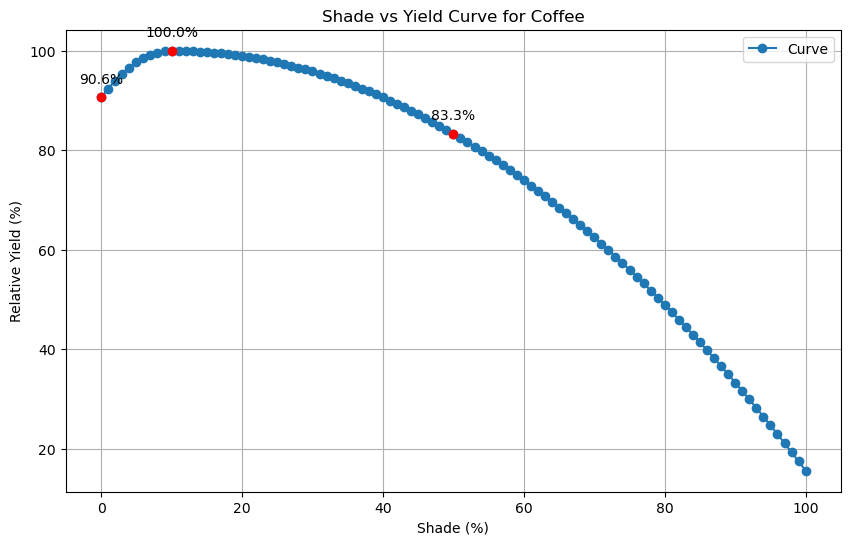

In [141]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Load curve
shade_vs_yield_curve_file = INPUT_DIR / "Shade_vs_Yield_Curve_coffee.csv"
shade_vs_yield_curve_COFFE = pd.read_csv(shade_vs_yield_curve_file)

mu_new = 10   # you could replace this with your random draw
shade_vs_yield_curve_COFFE = shift_peak_by_interpolation(shade_vs_yield_curve_COFFE, mu_new)


# Interpolator
f_interp = interp1d(
    shade_vs_yield_curve_COFFE['Shade (%)'],
    shade_vs_yield_curve_COFFE['Yield (%)'],
    kind='linear',
    fill_value='extrapolate'
)

# Points of interest
shade_points = [0, shade_vs_yield_curve_COFFE.loc[shade_vs_yield_curve_COFFE['Yield (%)'].idxmax(), 'Shade (%)'], 50]
yield_points = [float(f_interp(s)) for s in shade_points]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(shade_vs_yield_curve_COFFE['Shade (%)'], shade_vs_yield_curve_COFFE['Yield (%)'], marker='o', label='Curve')

# Annotate points
for s, y in zip(shade_points, yield_points):
    plt.scatter(s, y, color='red', zorder=5)
    plt.annotate(f"{y:.1f}%", (s, y), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Shade vs Yield Curve for Coffee')
plt.xlabel('Shade (%)')
plt.ylabel('Relative Yield (%)')
plt.grid()
plt.legend()
plt.show()


Derive a function to adjust crop yield based on canopy cover percentage.

In [142]:
from scipy.interpolate import interp1d

def estimate_new_yield(
    current_shade: float,
    current_yield: float,
    new_shade: float,
    shade_yield_df: pd.DataFrame
) -> float:
    """
    Estimate new yield based on change in shade, using relative scaling
    from the provided empirical shade–yield curve DataFrame.

    Args:
        current_shade (float): Current shade (%) [0–100]
        current_yield (float): Current observed yield (any unit)
        new_shade (float): Target new shade (%)
        shade_yield_df (pd.DataFrame): DataFrame with columns 'Shade (%)' and 'Yield (%)'

    Returns:
        float: Estimated new yield
    """
    interpolate_yield = interp1d(
        shade_yield_df["Shade (%)"],
        shade_yield_df["Yield (%)"],
        kind='linear',
        fill_value="extrapolate"
    )
    current_yield_pct = interpolate_yield(current_shade)
    new_yield_pct = interpolate_yield(new_shade)
    
    return current_yield * (new_yield_pct / current_yield_pct)


Try the function out

In [143]:
# Defeine a partial function to estimate new yield for coffee
from functools import partial
estimate_new_yield_coffe = partial(estimate_new_yield, 
                                    shade_yield_df = shade_vs_yield_curve_COFFE) 

# Example usage
current_shade = 50.0  # Current shade in %
current_yield = 1.0  # Current yield in kg/ha
new_shade = 30.0  # New target shade in %
new_yield = estimate_new_yield_coffe(current_shade, current_yield, new_shade)
print(f"Previous yield: {current_yield:.2f} kg/ha with {current_shade}% shade")
print(f"Estimated new yield: {new_yield:.2f} kg/ha with {new_shade}% shade")

Previous yield: 1.00 kg/ha with 50.0% shade
Estimated new yield: 1.15 kg/ha with 30.0% shade


Derive a function that adjusts the new yield given the canopy change across the canopy DataFrame.

In [144]:
def adjust_yield_based_on_new_canopy_cover(
    prev_crop_df: pd.DataFrame,
    new_crop_df: pd.DataFrame,
    spec_to_fcn: dict  # {str or list[str]: function}
) -> pd.DataFrame:
    """
    Adjust yield in new_crop_df based on canopy cover and scientific name-specific rules.

    Args:
        prev_crop_df (pd.DataFrame): DataFrame with previous canopy cover and yield.
        new_crop_df (pd.DataFrame): DataFrame to adjust.
        spec_to_fcn (dict): Dictionary where keys are scientific name(s) (str or list),
                            and values are functions that estimate new yield.

    Returns:
        pd.DataFrame: DataFrame with adjusted yield values.
    """
    df = new_crop_df.copy()

    # Merge previous yield and canopy cover
    matching_cols = ['site_id', 'Scientific name']
    df = df.merge(
        prev_crop_df[matching_cols + ['canopy_cover', 
                                      'Tonnes/plant',
                                      'Price/tonnes (USD)']],
        on=matching_cols,
        how='left',
        suffixes=('', '_previous')
    )

    df['Tonnes/plant_previous'] = df['Tonnes/plant']

    # Flatten the dictionary to {individual name: function}
    name_to_function = {}
    for names, func in spec_to_fcn.items():
        if isinstance(names, str):
            names = [names]
        for name in names:
            name_to_function[name] = func

    # Apply yield adjustment row-wise
    def compute_new_yield(row):
        name = row['Scientific name']
        func = name_to_function.get(name)
        if func and pd.notna(row['canopy_cover_previous']) and pd.notna(row['canopy_cover']) and pd.notna(row['Tonnes/plant_previous']):
            return func(
                current_shade=row['canopy_cover_previous'],
                current_yield=row['Tonnes/plant_previous'],
                new_shade=row['canopy_cover']
            )
        return row['Tonnes/plant_previous']

    df['Tonnes/plant'] = df.apply(compute_new_yield, axis=1)

    return df


Try the function out

In [145]:
# Example usage of the adjust_yield_based_on_new_canopy_cover function with multiple species
from matplotlib.pylab import f


prev_crop_df = canopy_crop_dict['present']  # Assuming 'present' is the previous crop DataFrame
new_crop_df = canopy_crop_dict[list(canopy_crop_dict.keys())[1]]  # Using the second sheet as the new crop DataFrame
spec_to_fcn = {
    'Coffea arabica': estimate_new_yield_coffe,
    'Theobroma cacao': estimate_new_yield_coffe  # Assuming the same function for cacao
}
updated_df = adjust_yield_based_on_new_canopy_cover(
    prev_crop_df=prev_crop_df,
    new_crop_df=new_crop_df,
    spec_to_fcn=spec_to_fcn
)

print(f"Previous crop DataFrame:")
print(tabulate(prev_crop_df, headers='keys', tablefmt='psql'))

print(f"Updated new crop DataFrame with adjusted yields for multiple species:")
print(tabulate(updated_df, headers='keys', tablefmt='psql'))

Previous crop DataFrame:
+----+----------------+---------------------+--------------+------------+-------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+
|    | Plot ID        | Region              | Region_key   |   latitude |   longitude | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   ca

Update the `make_exposure` function so that it uses the `canopy_df` from the given alternative scenario and applies the baseline exposure as a reference to adjust yield levels accordingly.


In [146]:
def make_exposures(canopy_df, exposure_present=None, spec_to_fcn=spec_to_fcn, value_unit="USD"):
    """
    Create an Exposures object from a canopy DataFrame.

    Args:
        canopy_df (pd.DataFrame): DataFrame containing canopy data.
        base_exposures (Exposures): Base exposures to use for the new exposures.
        value_unit (str): Unit of value for the exposures.

    Returns:
        Exposures: An Exposures object with the provided data.
    """
    
    if exposure_present is None:
        # If no base exposures are provided, create a new Exposures object
        exp = make_exposure_from_canopy_df(canopy_df, value_unit=value_unit)
    else:
        # Use the base exposures and update the DataFrame
        new_canopy_df = canopy_df.copy()
        prev_canopy_df = exposure_present.gdf.copy()
        updated_df = adjust_yield_based_on_new_canopy_cover(
            prev_crop_df=prev_canopy_df,
            new_crop_df=new_canopy_df,
            spec_to_fcn=spec_to_fcn
        )
        exp = make_exposure_from_canopy_df(updated_df, value_unit=value_unit)
            
    return exp


**Try out:** Show how to create the current and alternative exposures based on `canopy_df`, using the baseline scenario as a reference for adjusting yields.

In [147]:
# Make the exposures for the 'present' condition
exp_present = make_exposures(canopy_df=canopy_crop_dict['present'],
                         exposure_present= None,
                         spec_to_fcn=spec_to_fcn, 
                         value_unit="USD")

# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
#print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

# Make the exposures for the second condition (e.g., 'future' or 'alternative')
alternative_name = list(canopy_crop_dict.keys())[-4]  # Use the second condition
exp_new = make_exposures(canopy_df=canopy_crop_dict[alternative_name],
                         exposure_present=exp_present,
                         spec_to_fcn=spec_to_fcn, 
                         value_unit="USD")
print(f"Exposures object for {alternative_name} condition:")
#print(tabulate(exp_new.gdf, headers='keys', tablefmt='psql'))


# Sum over the 'value' column for Role == 'Main'
total_main_value = exp_present.gdf.loc[exp_present.gdf['Role'] == 'Main', 'value'].sum()
print(f"Total value for Role='Main': {total_main_value:.2f} {exp_present.value_unit}")

# Print the total value of the exposures with role equal to Main 
print(f"Total value for Role= '{alternative_name}': {exp_new.gdf.loc[exp_new.gdf['Role'] == 'Main', 'value'].sum():.2f} {exp_new.value_unit}")

2025-08-17 00:02:19,407 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
Exposures object for 'present' condition:
2025-08-17 00:02:19,412 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
Exposures object for present_adjusted_16 condition:
Total value for Role='Main': 1200.00 USD
Total value for Role= 'present_adjusted_16': 1130.92 USD


# 3 – Hazard 

Download the data 

https://www.climatologylab.org/terraclimate.html

🌡️ VPD – Vapour Pressure Deficit

We model Vapour Pressure Deficit (VPD) as a key climate hazard, similar to the paper Kath et al. (2022), Nature Food. The study provides a vulnerability curve linking mean VPD during the growing season to yield impacts for coffee.

We calculate the mean VPD over the crop-specific growing season: Mexico: June to December

In [148]:
import numpy as np
import xarray as xr
from scipy import sparse
from scipy.stats import genextreme
from climada.hazard import Hazard, Centroids
import pandas as pd

def _bootstrap_annual_fields(annual_da: xr.DataArray, n_years=100, start_year=2101, seed=None):
    """Resample annual FIELDS with replacement (preserves spatial patterns)."""
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, annual_da.sizes["year"], size=n_years)
    out = annual_da.isel(year=idx)
    return out.assign_coords(year=np.arange(start_year, start_year + n_years))

def _gev_sample_field(annual_da: xr.DataArray, n_years=100, start_year=2101,
                      invert=False, coupled=False, seed=None):
    """
    Fit GEV per grid and sample n_years (use for annual MAX, or MIN with invert=True).
    coupled=True uses the same quantile across all grid cells per synthetic year (adds coherence).
    """
    rng = np.random.default_rng(seed)
    Y = annual_da
    stacked = Y.stack(grid=("lat","lon"))
    lat, lon = Y["lat"], Y["lon"]

    # Fit params per grid cell
    params = []
    for i in range(stacked.sizes["grid"]):
        ts = stacked.isel(grid=i).values
        ts = ts[~np.isnan(ts)]
        if len(ts) < 10:
            params.append((np.nan, np.nan, np.nan))
            continue
        if invert: ts = -ts
        c, loc, scale = genextreme.fit(ts)
        params.append((c, loc, scale))
    params = np.array(params)

    ngrid = stacked.sizes["grid"]
    # Draw quantiles
    U = rng.random((n_years, 1 if coupled else ngrid))
    U = np.clip(U, 1e-10, 1-1e-10)
    if coupled:
        U = np.repeat(U, ngrid, axis=1)

    samples = np.full((n_years, ngrid), np.nan)
    valid = ~np.isnan(params[:,0])
    if np.any(valid):
        c, loc, scale = params[valid,0], params[valid,1], params[valid,2]
        samples[:, valid] = genextreme.ppf(U[:, valid], c, loc=loc, scale=scale)
    if invert: samples = -samples

    out = samples.reshape(n_years, len(lat), len(lon))
    return xr.DataArray(out,
                        coords={"year": np.arange(start_year, start_year+n_years),
                                "lat": lat, "lon": lon},
                        dims=["year","lat","lon"])

def create_hazard_from_nc_files(
    nc_files,
    varname,
    haz_type="HAZARD",
    units="unit",
    agg="max",
    months=None,                 # e.g. [5,6,7,8,9,10,11]
    nan_replacement=None,        # e.g. 0.0 to fill; None keeps NaNs (then convert later)
    # --- NEW: synthetic options ---
    synth=None,                  # None | "bootstrap" | "gev"
    synth_kwargs=None            # dict, e.g. {"n_years":200,"start_year":2101,"invert":False,"coupled":True,"seed":42}
):
    """
    Build a CLIMADA Hazard from NetCDFs, with optional longer synthetic annual series.
    - months is honored (subset BEFORE annual aggregation).
    - agg in {'max','sum','mean'}.
    - synth:
        * None: use observed annual series
        * 'bootstrap': resample annual fields (best for means; preserves spatial patterns)
        * 'gev': fit per-cell GEV and sample (best for block MAX/MIN)
    """
    if synth_kwargs is None:
        synth_kwargs = {}

    print(f"📂 Loading {len(nc_files)} files for '{varname}'...")
    ds_list = [xr.open_dataset(str(f))[varname] for f in nc_files]
    data = xr.concat(ds_list, dim="time")

    if months:
        print(f"📆 Filtering to months: {months}")
        data = data.sel(time=data['time.month'].isin(months))

    print(f"🧮 Aggregating by year: '{agg}'")
    grouped = data.groupby("time.year")
    if agg == "max":
        data_yr = grouped.max("time")
    elif agg == "sum":
        data_yr = grouped.sum("time")
    elif agg == "mean":
        data_yr = grouped.mean("time")
    else:
        raise ValueError(f"Unsupported aggregation: {agg}")

    # Synthetic extension (optional)
    if synth is None:
        annual_da = data_yr
    elif synth == "bootstrap":
        print("🔁 Synthetic years via BOOTSTRAP of annual fields.")
        annual_da = _bootstrap_annual_fields(data_yr, **synth_kwargs)
    elif synth == "gev":
        if agg != "max":
            print("⚠️ GEV is typically for block maxima/minima; agg!='max' used.")
        print("📈 Synthetic years via GEV sampling (per grid).")
        annual_da = _gev_sample_field(data_yr, **synth_kwargs)
    else:
        raise ValueError("synth must be None, 'bootstrap', or 'gev'.")

    print("📌 Reshaping to [year, lat*lon] ...")
    data_flat = annual_da.stack(site=("lat","lon")).transpose("year","site")
    data_arr = data_flat.values

    if nan_replacement is not None:
        print(f"🔄 Replacing NaNs with {nan_replacement}...")
        data_arr = np.nan_to_num(data_arr, nan=nan_replacement)

    print("🧱 Building sparse intensity ...")
    intensity = sparse.csr_matrix(data_arr)

    print("🗺️ Centroids ...")
    latlon = data_flat.site.to_index().to_frame(index=False)
    cents = Centroids(lat=latlon["lat"].values, lon=latlon["lon"].values)

    years = annual_da["year"].values
    hazard = Hazard(
        haz_type=haz_type,
        intensity=intensity,
        fraction=intensity.copy().astype(bool),
        centroids=cents,
        units=units,
        event_id=np.arange(len(years)),
        frequency=np.ones(len(years))/len(years),
        date=np.array([pd.Timestamp(f"{y}-01-01").toordinal() for y in years]),
        event_name=[f"year_{y}" for y in years]
    )
    return hazard


📂 Loading 37 files for 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year: 'mean'
🔁 Synthetic years via BOOTSTRAP of annual fields.
📌 Reshaping to [year, lat*lon] ...
🔄 Replacing NaNs with 0.0...
🧱 Building sparse intensity ...
🗺️ Centroids ...
📂 Loading 30 files for 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year: 'mean'
🔁 Synthetic years via BOOTSTRAP of annual fields.
📌 Reshaping to [year, lat*lon] ...
🔄 Replacing NaNs with 0.0...
🧱 Building sparse intensity ...
🗺️ Centroids ...


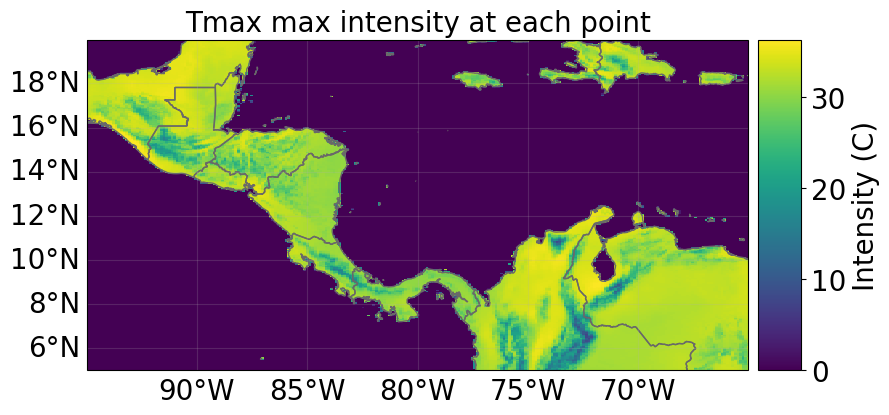

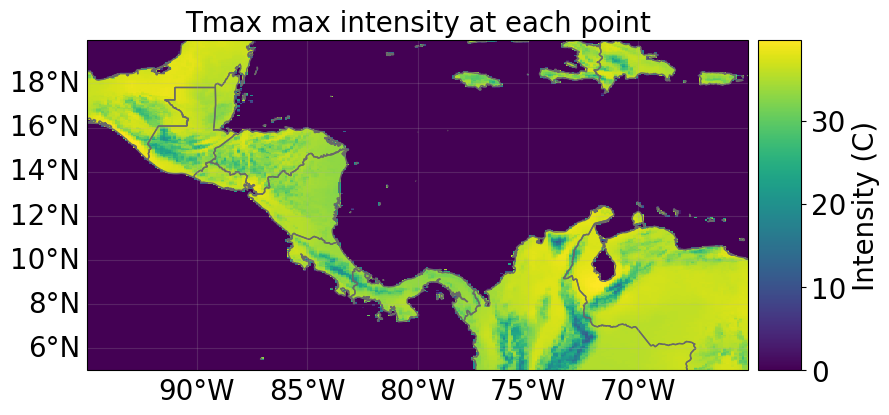

In [149]:
# Determine the corresponding parameters for the hazard type
nc_files = {'today': [], 'future': []}
haz_dict  = {'today': Hazard, 'future': Hazard}

if hazard_type == 'VPD':
    agg    = 'mean'
    varname = 'vpd'
    units   = 'kPa'
    months  = [5,6,7,8,9,10,11]
    nc_files['today']  = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_vpd_*_CA.nc"))

elif hazard_type == 'Tmax':
    agg    = 'mean'  # use 'max' if you want block maxima + GEV
    varname = 'tmax'
    units   = 'C'
    months  = [5,6,7,8,9,10,11]
    nc_files['today']  = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_tmax_*_CA.nc"))

# Build hazards
for key in nc_files:
    haz_dict[key] = create_hazard_from_nc_files(
        nc_files[key],
        varname=varname,
        haz_type=hazard_type,
        units=units,
        agg=agg,
        months=months,
        nan_replacement=0.0,              # or None if you prefer to keep NaNs pre-sparse
        # --- turn on one of these when you want a longer series ---
        synth="bootstrap", synth_kwargs={"n_years": 200, "start_year": 2101, "seed": 42}
        #synth="gev",       synth_kwargs={"n_years": 200, "start_year": 2101, "invert": False, "coupled": True, "seed": 42}
    )
    haz_dict[key].plot_intensity(0)


In [150]:
# from utils_cb import create_hazard_from_nc_files
# from climada.hazard import Hazard

# # Determine the corresponding parameters for the hazard type
# nc_files = {'today': [], 'future': []}
# haz_dict = {'today': Hazard, 'future': Hazard}

# if hazard_type == 'VPD':
#     agg = 'mean'
#     varname = 'vpd'
#     nc_files['today'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_CA.nc"))
#     nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_vpd_*_CA.nc"))
#     units = 'kPa'
#     months = [5, 6, 7, 8, 9, 10, 11]  # April to November
# elif hazard_type == 'Tmax':
#     agg = 'mean'
#     varname = 'tmax'
#     nc_files['today'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_CA.nc"))
#     nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_tmax_*_CA.nc"))
#     units = 'C'
#     months = [5, 6, 7, 8, 9, 10, 11] # April to November


# # Store the hazard type and parameters in a dictionary
# for key in nc_files:
#     haz_dict[key] = create_hazard_from_nc_files(
#                         nc_files[key],
#                         varname=varname,
#                         haz_type=hazard_type,
#                         units=units,
#                         agg=agg,
#                         months=months,
#                         nan_replacement=0.0  # Use NaN to keep sparse matrix
#                     )
#     # Plot the hazard object
#     haz_dict[key].plot_intensity(0)


# 4 – Impact Function (Vulnerability)

As mentioned in Step 3, the vulnerability curve is sourced from the following study: [Kath et al. (2022), *Nature Food*](https://www.nature.com/articles/s43016-022-00614-8).

We begin by creating a basic default impact function and then adjust it based on canopy cover, which provides a cooling effect that can reduce vulnerability to heat-related losses.

In [151]:
from climada.entity import ImpactFunc

def impact_func_from_kath(
    file_path: str,
    intensity_col: str,
    yield_col: str,
    only_yield_losses: bool = True,
    haz_type: str = "VPD",
    unit: str = "kPa",
    if_id: int = 1,
    name: str = "Impact Function from CSV"
) -> ImpactFunc:
    """
    Create a CLIMADA ImpactFunc directly from a CSV file with intensity and yield(-log) data.

    Parameters:
    - file_path: path to CSV
    - intensity_col: column name for hazard intensity (e.g. 'Mean_VPD_kPa')
    - yield_col: column name for yield or log-yield (e.g. 'Effect_Central')
    - is_log: True if yield_col is in log scale
    - only_yield_losses: whether to filter for only negative yield impacts
    - haz_type: CLIMADA hazard type string (e.g. "VPD")
    - unit: unit for intensity (e.g. "kPa", "°C")
    - if_id: Impact function ID
    - name: Name for the impact function

    Returns:
    - ImpactFunc
    """
    df = pd.read_csv(file_path)

    if yield_col not in df.columns or intensity_col not in df.columns:
        raise ValueError("Specified columns not found in the CSV.")

    x = df[intensity_col].values
    y = df[yield_col].values

    # Optional filtering
    if only_yield_losses:
        mask = y < 0
        x, y = x[mask], y[mask]

    # Convert to linear scale if needed
    yield_vals = np.exp(y)

    # Normalize to max yield (best-case baseline)
    baseline = np.max(yield_vals)
    mdd = 1 - (yield_vals / baseline)
    mdd = np.clip(mdd, 0, 1)

    paa = np.ones_like(mdd)

    # Build and return
    impf = ImpactFunc(
        id=if_id,
        name=name,
        haz_type=haz_type,
        intensity=x,
        mdd=mdd,
        paa=paa,
        intensity_unit=unit
    )
    impf.check()
    return impf

In [152]:
# import numpy as np
# import pandas as pd
# from climada.entity import ImpactFunc

# def impact_func_from_csv(
#     file_path: str,
#     intensity_col: str,              # x-axis (e.g., 'Mean_VPD_kPa' or 'Mean_Tmax_C')
#     value_col: str,                  # y-axis from the paper (see mode)
#     mode: str = "log_effect",        # 'log_effect' (Fig.1) or 'yield' (Fig.2)
#     haz_type: str = "VPD",           # e.g., 'VPD', 'TMAX', 'TR', ...
#     unit: str = "kPa",               # e.g., 'kPa', '°C'
#     if_id: int = 1,
#     name: str = "Impact Function from CSV",
#     # --- baselining (kept simple) ---
#     baseline_max_intensity: float = None,  # use mean of points with x <= this as baseline (good for pre-threshold)
#     avg_yield: float = None,               # only for mode='yield' (if None, inferred from baseline_max_intensity or max)
#     # --- optional post-threshold “kink” (OFF by default) ---
#     threshold: float = None,         # set e.g. 0.82 (VPD) or 29.2 (°C) if you want a kink
#     half_per_delta: float = None,    # e.g. 0.1 (VPD): +0.1 above threshold halves rel_y; for °C you might use 1.0
#     enforce_threshold: bool = False, # leave False to use the CSV curve as-is
#     # --- shaping ---
#     only_losses: bool = True,        # drop zero-damage points after computing mdd
#     monotone: bool = True            # enforce non-decreasing mdd with intensity
# ) -> ImpactFunc:
#     """
#     Generic CSV -> CLIMADA ImpactFunc.

#     mode='log_effect':
#         - value_col holds the centred smooth on the log-link (Fig.1).
#         - Compute baseline on effect scale (by x <= baseline_max_intensity if given, else use max(effect)).
#         - rel_y = exp(effect - baseline_effect).

#     mode='yield':
#         - value_col holds predicted yields (Fig.2).
#         - avg_yield: if None, use mean(y[x<=baseline_max]) if provided, else max(y).
#         - rel_y = y / avg_yield.

#     Optional kink:
#         If threshold and half_per_delta are set and enforce_threshold=True,
#         then for x > threshold: rel_y = rel_y(threshold) * exp( ln(0.5) * (x - threshold) / half_per_delta )
#     """
#     df = pd.read_csv(file_path)
#     if intensity_col not in df.columns or value_col not in df.columns:
#         raise ValueError("Specified columns not found in the CSV.")

#     x = df[intensity_col].astype(float).to_numpy()
#     v = df[value_col].astype(float).to_numpy()

#     # --- build relative yield rel_y ---
#     if mode == "log_effect":
#         # baseline on log-effect scale
#         if baseline_max_intensity is not None and np.any(x <= baseline_max_intensity):
#             s0 = np.nanmean(v[x <= baseline_max_intensity])
#         else:
#             s0 = np.nanmax(v)  # best-case effect
#         rel_y = np.exp(v - s0)

#     elif mode == "yield":
#         # baseline on yield scale
#         if avg_yield is None:
#             if baseline_max_intensity is not None and np.any(x <= baseline_max_intensity):
#                 avg_y = np.nanmean(v[x <= baseline_max_intensity])
#             else:
#                 avg_y = np.nanmax(v)
#         else:
#             avg_y = float(avg_yield)
#         rel_y = np.where(avg_y > 0, v / avg_y, 0.0)
#     else:
#         raise ValueError("mode must be 'log_effect' or 'yield'.")

#     # --- optional: impose post-threshold drop (kink) ---
#     if enforce_threshold and (threshold is not None) and (half_per_delta is not None) and (half_per_delta > 0):
#         mask = x > threshold
#         if np.any(mask):
#             # rel_y at/just below the threshold
#             left = rel_y[x <= threshold]
#             r_star = np.nanmax(left) if left.size else 1.0
#             k = np.log(0.5) / float(half_per_delta)  # +half_per_delta → ×0.5
#             rel_y[mask] = r_star * np.exp(k * (x[mask] - threshold))

#     # --- damage fraction ---
#     mdd = np.clip(1.0 - rel_y, 0.0, 1.0)

#     if only_losses:
#         keep = mdd > 0
#         x, mdd = x[keep], mdd[keep]

#     # sort & optionally enforce monotone non-decreasing
#     order = np.argsort(x)
#     x, mdd = x[order], mdd[order]
#     if monotone and mdd.size:
#         mdd = np.maximum.accumulate(mdd)

#     impf = ImpactFunc(
#         id=if_id,
#         name=name,
#         haz_type=haz_type,
#         intensity=x,
#         mdd=mdd,
#         paa=np.ones_like(mdd),
#         intensity_unit=unit,
#     )
#     impf.check()
#     return impf


For cacao 

### Cacao — heat & VPD (notebook cheatsheet)

- **Heat (Tmax):** photosynthesis peaks ~**31–33 °C**; losses kick in above **~33–35 °C**.  
  *ImpactFunc defaults:* `T_opt = 32 °C`, `T50 = 35 °C`, `T_maxloss = 38 °C` → piecewise damage 0→1.

- **VPD (air dryness):** cacao is sensitive; yield declines **monotonically** as VPD rises (shade/water mitigate).  
  *ImpactFunc defaults:* logistic relative yield with `V50 ≈ 1.6 kPa`, slope `k ≈ 3.5`, benign floor `vpd_floor ≈ 0.6 kPa`.

- **Damage as relative loss:**  
  \( \mathrm{mdd}(x) = \max\!\big(0,\ 1 - \hat{y}(x)/\bar{y}\big) \)  
  Use \(\bar{y}\) = local **pre-stress** baseline yield.

**Main references (short list)**  
- Lahive, F., Hadley, P., & Daymond, A. (2019). *The physiological responses of cacao to the environment and climate change*.  
- Balasimha, D. et al. (1991). *Influence of environmental factors (light, temperature, VPD) on cocoa photosynthesis*.  
- Baligar, V.C. et al. (2008). *PPFD, CO₂ and VPD effects on photosynthesis in cacao seedlings*.  
- Della Sala, P. et al. (2021). *Atmospheric and soil water stress impacts on cacao production in West Africa*.  
- Mensah, E.O. et al. (2022). *Shade × elevated temperature: cocoa physiology; Topt ~31–33 °C*.  
- Mateus-Rodríguez, J.F. et al. (2023). *Elevated temperature/CO₂ simulations in cacao*.  
- Asare, R. et al. (2019). *On-farm cocoa yields increase with shade-tree canopy cover*.  
- Mensah, E.O. (2023). *Cocoa Under Heat and Drought Stress* (book chapter).  
- Adet, L. et al. (2024). *Seasonal rainfall reduction experiments: cocoa performance & yield*.


In [153]:
import numpy as np
from climada.entity import ImpactFunc

# Create an impact function for Cacao based on Tmax
def cacao_impf_tmax(
    T: np.ndarray,               # intensity grid (°C), e.g. seasonal mean/max during flowering
    T_opt: float = 32.0,         # photosynthesis optimum (31–33 °C supported by literature)
    T50: float = 35.0,           # ~50% relative yield at this Tmax
    T_maxloss: float = 38.0,     # near-total loss beyond this
    if_id: int = 2, name="Cacao | Tmax", unit="°C"
) -> ImpactFunc:
    T = np.asarray(T, float)
    mdd = np.zeros_like(T, float)
    # No damage up to T_opt
    mdd[T <= T_opt] = 0.0
    # Linear ramp T_opt -> T50 -> T_maxloss
    sel = (T > T_opt) & (T <= T50)
    mdd[sel] = (T[sel]-T_opt)/(T50-T_opt) * 0.5
    sel = (T > T50) & (T <= T_maxloss)
    mdd[sel] = 0.5 + (T[sel]-T50)/(T_maxloss-T50) * 0.5
    mdd[T > T_maxloss] = 1.0
    return ImpactFunc(id=if_id, name=name, haz_type="TMAX",
                      intensity=np.sort(T), mdd=np.maximum.accumulate(mdd[np.argsort(T)]),
                      paa=np.ones_like(T), intensity_unit=unit)


# Create an impact function for Cacao based on VPD
def cacao_impf_vpd(
    V: np.ndarray,               # intensity grid (kPa) for the relevant season
    V50: float = 1.6,            # VPD at 50% relative yield (tunable)
    k: float = 3.5,              # slope/steepness; larger = steeper drop near V50
    vpd_floor: float = 0.6,      # below this, assume no damage under shade
    if_id: int = 2, name="Cacao | VPD", unit="kPa"
) -> ImpactFunc:
    V = np.asarray(V, float)
    # Relative yield r(V) = 1 / (1 + exp(k*(V - V50)))
    r = 1.0/(1.0 + np.exp(k*(V - V50)))
    # Flatten pre-stress range (capped at r=1)
    r[V <= vpd_floor] = 1.0
    mdd = np.clip(1.0 - r, 0.0, 1.0)
    order = np.argsort(V)
    return ImpactFunc(id=if_id, name=name, haz_type="VPD",
                      intensity=V[order], mdd=np.maximum.accumulate(mdd[order]),
                      paa=np.ones_like(V), intensity_unit=unit)


### 4.1 – Get the default impact functions

2025-08-17 00:03:02,029 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


array([<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
       <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
       <Axes: title={'center': 'Tmax 2: Assumed Yield Loss (Cacao)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
      dtype=object)

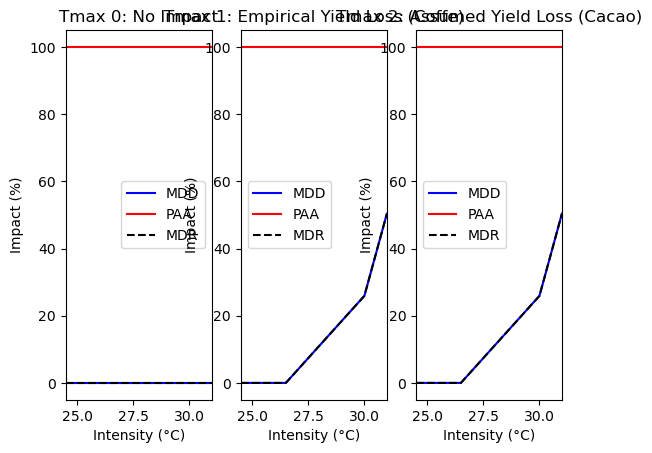

In [154]:
#from utils_cb import impact_func_from_kath

import pandas as pd
import numpy as np
from climada.entity import ImpactFuncSet


# Create an ImpactFuncSet with the VPD impact function
imp_fun_set_base = ImpactFuncSet()

## Make the impact function for coffee with id 1 
# Coffe has id # 1, Banana has id 2, Cacao has id 3
if hazard_type.upper() == 'TMAX':
    # Coffee impact function based on Tmax
    impf_coffe = impact_func_from_kath(
        file_path= "Data/tasmax_effect_approximation_coffe.csv",
        intensity_col="Mean_Tasmax_C",
        yield_col="Effect_Central",
        haz_type="Tmax",
        unit="°C",
        if_id= 1,
        name="Empirical Yield Loss (Coffe)"
    )
    # Cacao impact function based on Tmax
    impf_cacao = cacao_impf_tmax(
        T=impf_coffe.intensity,
        if_id=2,
        name="Assumed/Prior Yield Loss (Cacao)"
    )
elif hazard_type.upper() == 'VPD':
    # Coffee impact function based on VPD
    impf_coffe = impact_func_from_kath(
        file_path= "Data/vpd_effect_approximation.csv",
        intensity_col="Mean_VPD_kPa",
        yield_col="Effect_Central",
        haz_type="VPD",
        unit="kPa",
        if_id= 1,
        name="Empirical Yield Loss (Coffe)"
    )
    # Cacao impact function based on VPD
    impf_cacao = cacao_impf_vpd(
        V=impf_coffe.intensity,
        if_id=2,
        name="Assumed/Prior Yield Loss (Cacao)"
    )

#impf_coffe.plot()

# Adjust the impact function intensity to be zero before the increasing values to only account for negative impacts
for idx, value in enumerate(impf_coffe.mdd):
   # print(f"Index: {idx}, Value: {value}")
    #print(f"Intensity: {impf_coffe.mdd}")
    if value > 0:
        impf_coffe.mdd[idx] = 0.0
    else:
        break

#impf_coffe.plot()

## Make the non impact function for coffee with id 0
impf_zero = copy.deepcopy(impf_coffe)
impf_zero.id = 0  # Set the ID to 0 for no impact
impf_zero.name = "No Impact"
impf_zero.mdd = np.zeros_like(impf_coffe.mdd)  # Set all values to zero
#impf_zero.plot()

# Make the cacao impact function based on the assumption that it is the same as coffee
# This is a prior assumption, not based on empirical data
# Adjust the intensity to be zero before the increasing values to only account for negative impacts
impf_cacao = copy.deepcopy(impf_coffe)
impf_cacao.id = 2
impf_cacao.name = "Assumed Yield Loss (Cacao)"


# Add the impact function to the ImpactFuncSet
imp_fun_set_base.append(impf_zero)
imp_fun_set_base.append(impf_coffe)
imp_fun_set_base.append(impf_cacao)

# Plot the impact function set
imp_fun_set_base.plot()


**Create a DataFrame** to store the default impact function IDs, where:

- `0` → No impact  
- `1` → Coffee  
- `2` → Cacao


In [155]:

default_impact_function_id = {0: ['Inga spp.', 'Citrus aurantium', 'Citrus sinensis', 'Pouteria sapota', 'Artocarpus altilis', 'Persea americana', 'Musa spp.', 'Gliricidia sepium'],
                              1: ['Coffea arabica'],
                              2: ['Theobroma cacao']
                            }

# Flatten to list of (Scientific name, impf_id_default)
records = [
    {'Scientific name': species, 'impf_id_default': impf_id}
    for impf_id, species_list in default_impact_function_id.items()
    for species in species_list
]

# Create DataFrame
impf_default_df = pd.DataFrame(records)
print("Default Impact Function DataFrame:")
print(tabulate(impf_default_df, headers='keys', tablefmt='psql'))

Default Impact Function DataFrame:
+----+--------------------+-------------------+
|    | Scientific name    |   impf_id_default |
|----+--------------------+-------------------|
|  0 | Inga spp.          |                 0 |
|  1 | Citrus aurantium   |                 0 |
|  2 | Citrus sinensis    |                 0 |
|  3 | Pouteria sapota    |                 0 |
|  4 | Artocarpus altilis |                 0 |
|  5 | Persea americana   |                 0 |
|  6 | Musa spp.          |                 0 |
|  7 | Gliricidia sepium  |                 0 |
|  8 | Coffea arabica     |                 1 |
|  9 | Theobroma cacao    |                 2 |
+----+--------------------+-------------------+


### 4.2 Add mapped impact function IDs to the exposure, based on site and canopy level


In [156]:
import copy
import numpy as np
import pandas as pd
from tabulate import tabulate

def generate_custom_impact_function_IDs_by_canopy_df(
    impf_default_df: pd.DataFrame,
    canopy_df: pd.DataFrame,
    hazard_type: str,
    ignore_impf_ids: list = [0] # Default to ignoring ID 0 (no impact) if not specified
):
    """
    Generate custom impact function IDs based on canopy cover and assign new IDs.

    Args:
        impf_default_df (pd.DataFrame): Columns ['Scientific name', 'impf_id_default']
        canopy_df (pd.DataFrame): Columns ['site_id', 'Scientific name', 'canopy_cover']
        imp_fun_set (ImpactFuncSet): Base impact function set to copy and expand.
        adjust_fcn (function): Function to adjust the base impact function using canopy_cover.
        hazard_type (str): Hazard type (e.g. "TR").
        ignore_impf_ids (list): List of impf IDs to skip (default: [0] = no impact)

    Returns:
        Tuple[pd.DataFrame, ImpactFuncSet]: 
            - Updated DataFrame with new impact function column `impf_{hazard_type}`
            - Modified ImpactFuncSet with newly added functions
    """

    # get the site_id and scientific name from the canopy_df
    df_site_canopy = canopy_df[['site_id', 'Scientific name']].drop_duplicates()

    # Merge canopy and default impact function assignments
    df_impf_id_map = df_site_canopy.merge(impf_default_df, on='Scientific name', how='left')

    # Copy the impact function set
    #imp_fun_set_new = copy.deepcopy(imp_fun_set)

    # Get next available ID
    next_id = impf_default_df['impf_id_default'].max() + 1

    # For caching and reuse
    species_func_cache = {}

    # Store new IDs
    new_impf_ids = []

    for _, row in df_impf_id_map.iterrows():
        site_id = row['site_id']
        species_name = row['Scientific name']
        base_impf_id = row['impf_id_default']

        if pd.isna(base_impf_id) or base_impf_id in ignore_impf_ids:
            # Use original base ID (e.g. 0 = no impact)
            new_impf_ids.append(base_impf_id)
            continue

        # Use a cache key (species, base ID) to avoid duplication
        key = (site_id, species_name, base_impf_id)

        if key in species_func_cache:
            new_impf_ids.append(species_func_cache[key])
            continue

        # Get base function and generate adjusted one
        species_func_cache[key] = next_id
        new_impf_ids.append(next_id)
        next_id += 1

    # Assign new column to the DataFrame
    df_impf_id_map = df_impf_id_map.copy()
    impf_col_name = f"impf_{hazard_type}"
    df_impf_id_map[impf_col_name] = new_impf_ids


    return df_impf_id_map

Test the function

In [157]:
# Example usage
df_impf_id_map = generate_custom_impact_function_IDs_by_canopy_df(
    impf_default_df=impf_default_df,
    canopy_df= canopy_crop_dict['present'],
    hazard_type=hazard_type
)

# Print the DataFrame with new impact function IDs
print("DataFrame with new impact function IDs:")
print(tabulate(df_impf_id_map, headers='keys', tablefmt='psql'))

DataFrame with new impact function IDs:
+----+-----------+--------------------+-------------------+-------------+
|    |   site_id | Scientific name    |   impf_id_default |   impf_Tmax |
|----+-----------+--------------------+-------------------+-------------|
|  0 |         0 | Persea americana   |                 0 |           0 |
|  1 |         0 | Musa spp.          |                 0 |           0 |
|  2 |         0 | Citrus aurantium   |                 0 |           0 |
|  3 |         0 | Artocarpus altilis |                 0 |           0 |
|  4 |         0 | Theobroma cacao    |                 2 |           3 |
|  5 |         0 | Coffea arabica     |                 1 |           4 |
|  6 |         0 | Gliricidia sepium  |                 0 |           0 |
|  7 |         0 | Inga spp.          |                 0 |           0 |
|  8 |         0 | Pouteria sapota    |                 0 |           0 |
|  9 |         0 | Citrus sinensis    |                 0 |           0 

Add the impf_Tmax to the exposure id for each canopy

In [158]:
def make_exposures_from_canopy_df(
    canopy_df: pd.DataFrame,
    exposure_present: Exposures = None,
    spec_to_fcn: dict = None,
    value_unit: str = "USD",
    impf_default_df=impf_default_df,
    ignore_impf_ids=[0],
    hazard_type: str = hazard_type
) -> Exposures:
    """
    Create an Exposures object from a canopy DataFrame.

    Args:
        canopy_df (pd.DataFrame): DataFrame containing canopy data.
        exposure_present (Exposures): Base exposures to use for the new exposures.
        spec_to_fcn (dict): Dictionary where keys are scientific name(s) (str or list),
                            and values are functions that estimate new yield.
        value_unit (str): Unit of value for the exposures.

    Returns:
        Exposures: An Exposures object with the provided data.
    """

    # Get the custom impact function IDs from the canopy DataFrame
    df_impf_id_map = generate_custom_impact_function_IDs_by_canopy_df(
        impf_default_df=impf_default_df,
        canopy_df=canopy_df,
        hazard_type=hazard_type,
        ignore_impf_ids= ignore_impf_ids
    )
    
    # Add to the canopy DataFrame
    canopy_df = canopy_df.merge(df_impf_id_map[['site_id', 'Scientific name', f'impf_{hazard_type}']],
                                on=['site_id', 'Scientific name'],
                                how='left')
   
    # make the exposures
    exp = make_exposures(
        canopy_df=canopy_df,
        exposure_present=exposure_present,
        spec_to_fcn=spec_to_fcn,
        value_unit=value_unit
    )

    return exp


**Try the function** and verify that the generated exposure also includes an assigned impact function ID.

In [159]:
# Example usage 
exp_present = make_exposures_from_canopy_df(canopy_df = canopy_crop_dict['present'],
                                            exposure_present= None,
                                            spec_to_fcn = spec_to_fcn)

# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

Exposures object for 'present' condition:
+----+----------------+---------------------+--------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------+------------------+---------+------------------------------+
|    | Plot ID        | Region              | Region_key   | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |   site_id |   Per-tree shading (%) scaled |   Shade contr

### 4.3 Adjust the impact function for cooling effects and create unique impact function sets for each compositions

**Create an adjustment function** that modifies the hazard intensity based on canopy cover, reflecting the cooling and protective effects of increased shade.

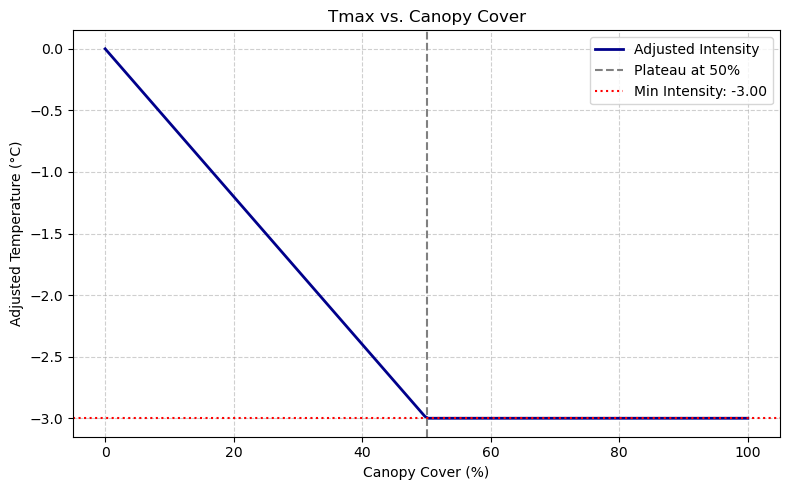

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# Updated function definition
def helper_create_adj_func(max_cooling=3, plateau_at=50, sensitivity=None):
    """
    Creates an adjustment function for canopy cover effects on the intensity of a hazard.
    Args:
        max_cooling (float): Maximum cooling effect (°C or kPa).
        plateau_at (float): Canopy cover percentage at which the cooling effect plateaus.
        sensitivity (float, optional): Sensitivity factor for VPD reduction. If None, no
            sensitivity adjustment is applied.
    Returns:
        function: A function that takes a hazard intensity and canopy cover array
                  and returns the adjusted hazard intensity.
    """
    slope = -max_cooling / plateau_at

    def adjustment(intensity, canopy_cover):
        """Applies adjustment to hazard intensity based on canopy cover."""
        if not isinstance(canopy_cover, np.ndarray):
            canopy_cover = np.array(canopy_cover)
        canopy = np.clip(canopy_cover, 0, 100)
        temp_reduction = np.where(
            canopy <= plateau_at,
            slope * canopy,
            -max_cooling
        )
        if sensitivity is not None:
            reduction = -sensitivity * temp_reduction
        else:
            reduction = temp_reduction
        return intensity + reduction

    return adjustment

# Example for plotting
canopy = np.linspace(0, 100, 200)

if hazard_type.upper() == 'TMAX':
    base_intensity = 0  # °C
    adjust_fcn = helper_create_adj_func()
    ylabel = "Adjusted Temperature (°C)"
    title = "Tmax vs. Canopy Cover"
elif hazard_type.upper() == 'VPD':
    base_intensity = 0  # kPa
    adjust_fcn = helper_create_adj_func(sensitivity=-0.15)
    ylabel = "Adjusted VPD (kPa)"
    title = "VPD vs. Canopy Cover"
else:
    raise ValueError("Unsupported hazard type")

# Calculate adjusted values
adj_intensity = adjust_fcn(base_intensity, canopy)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, adj_intensity, label="Adjusted Intensity", color="darkblue", linewidth=2)
plt.axvline(50, linestyle='--', color='gray', label="Plateau at 50%")
plt.axhline(adj_intensity[-1], linestyle=':', color='red', label=f'Min Intensity: {adj_intensity[-1]:.2f}')
plt.title(title)
plt.xlabel("Canopy Cover (%)")
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


**Create a function** that adjusts the impact function using the previously defined hazard intensity adjustment function, updating vulnerability curves accordingly.

In [161]:
def adjust_impf_by_canopy(impf, adjust_fcn, new_id, current_canopy=50, new_name=None):
    """
    Adjust an impact function based on a canopy adjustment function.

    Parameters:
    -----------
    impf : ImpactFuncSet or compatible object
        Original impact function to be adjusted.
    adjust_fcn : function
        Function that modifies intensity based on canopy cover: f(intensity, canopy).
    new_id : int
        ID for the new adjusted impact function.
    current_canopy : float
        Canopy cover percentage to apply (default is 50).

    Returns:
    --------
    adj_impf : ImpactFunc object
        A copy of the original impact function with adjusted intensity and MDR.
    """
    # Copy the original impact function
    adj_impf = copy.deepcopy(impf)

    # Full original intensity range
    orig_intensity = impf.intensity
    orig_min, orig_max = orig_intensity.min(), orig_intensity.max()

    # Use fine spacing to assess max shift
    test_intensity = np.linspace(orig_min, orig_max, 500)
    adjusted = adjust_fcn(test_intensity, current_canopy)
    shift = adjusted - test_intensity
    max_shift = np.abs(shift).max()

    # Extend range to ensure coverage
    n_points = 50
    intensity_range = np.linspace(orig_min - max_shift, orig_max + max_shift, n_points)


    # Check paa logic
    if np.all(impf.paa == 1):
        adj_intensity = adjust_fcn(intensity_range, current_canopy)
        adjusted_mdr = impf.calc_mdr(adj_intensity)

        # Update impact function
        adj_impf.intensity = intensity_range
        adj_impf.mdd = adjusted_mdr
        adj_impf.paa = np.ones_like(intensity_range)
        adj_impf.id = new_id
        if new_name is not None:
            adj_impf.name = new_name

    else:
        print('⚠️ Warning: impf.paa is not all ones, adjustment skipped.')

    return adj_impf


Demonstrate the adjusted imapct function

<Axes: title={'center': 'Tmax 1: Adjusted Impact Function (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>

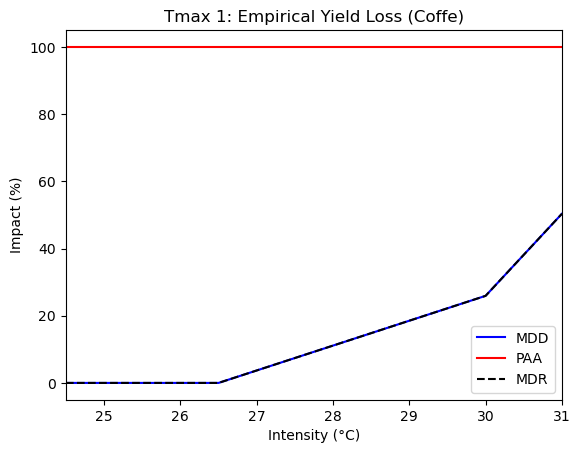

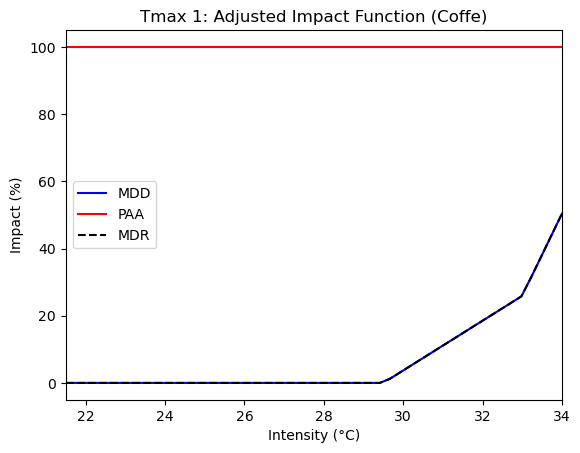

In [162]:
new_id = 1
adj_impf = adjust_impf_by_canopy(impf_coffe, adjust_fcn, new_id, current_canopy=70, new_name="Adjusted Impact Function (Coffe)")

impf_coffe.plot()
adj_impf.plot()

**Create a function** that generates a unique impact function set for each canopy composition, incorporating canopy-based adjustments to hazard intensity and vulnerability.

In [163]:
def create_adjusted_impact_function_set(
    canopy_df: pd.DataFrame,
    adjust_fcn,
    imp_fun_set_base: ImpactFuncSet = imp_fun_set_base,
    df_impf_id_map: pd.DataFrame = df_impf_id_map,
    hazard_type: str = hazard_type,
    ignore_impf_ids: list = [0]  # Default to ignoring ID 0 (no impact) if not specified
):
    """
    Create adjusted impact functions using pre-assigned IDs and canopy cover.

    Args:
        df_impf_id_map (pd.DataFrame): Must contain ['site_id', 'Scientific name', 'impf_id_default', 'impf_{hazard_type}']
        df_site_canopy (pd.DataFrame): Must contain ['site_id', 'Scientific name', 'canopy_cover']
        imp_fun_set_base (ImpactFuncSet): Original function set.
        adjust_fcn (function): Canopy adjustment function.
        hazard_type (str): Hazard type (e.g., "TMAX")

    Returns:
        ImpactFuncSet: New ImpactFuncSet with adjusted functions added.
    """
    # get the site_id and scientific name from the canopy_df
    df_site_canopy = canopy_df[['site_id', 'Scientific name', 'canopy_cover']].drop_duplicates()


    # Merge canopy cover into the ID mapping DataFrame
    df_merged = df_impf_id_map.merge(
        df_site_canopy,
        on=['site_id', 'Scientific name'],
        how='left'
    )

    # Copy original function set
    imp_fun_set_new = copy.deepcopy(imp_fun_set_base)
    seen_ids = set()

    # Iterate through the merged DataFrame to create adjusted functions
    for _, row in df_merged.iterrows():
        site_id = row['site_id']
        base_id = row['impf_id_default']
        new_id = row[f'impf_{hazard_type}']
        canopy = row['canopy_cover']


        if pd.isna(new_id) or new_id in ignore_impf_ids or new_id in seen_ids:
            # Skip if no new ID or already seen
            continue

        base_impf = imp_fun_set_base.get_func(hazard_type, base_id) # Get the base impact function by hazard type and ID
        adjusted_func = adjust_impf_by_canopy(
            base_impf,
            adjust_fcn=adjust_fcn,
            new_id=new_id,
            current_canopy=canopy, 
            new_name=f"{row['Scientific name']} site {site_id}"
        )

        imp_fun_set_new.append(adjusted_func)
        seen_ids.add(new_id)

    return imp_fun_set_new

Try out the function

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 2: Assumed Yield Loss (Cacao)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 3: Theobroma cacao site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 4: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 5: Theobroma cacao site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 6: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 7: Theobroma cacao site 2'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 8: Coffea arabica site 2'}, xlabel='Intensity (°C)', 

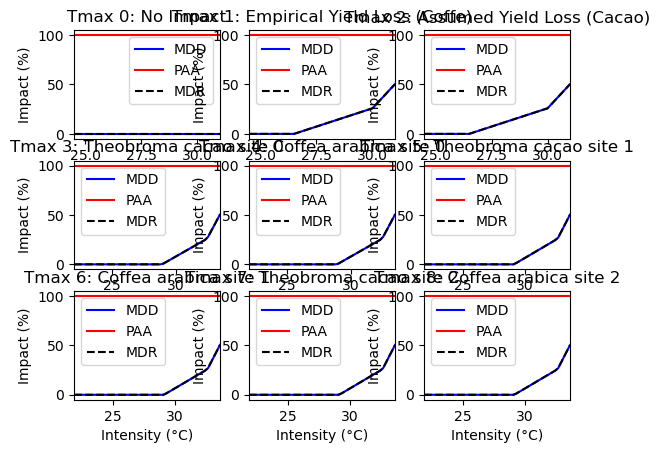

In [164]:
adjusted_impf_set = create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict[list(canopy_crop_dict.keys())[0]],  # Use the first sheet as the base
    adjust_fcn=adjust_fcn
)

adjusted_impf_set.plot()

# 5 – Cost and Income

This is a new object in CLIMADA that helps calculate revenue streams for cost–benefit analysis  
and supports adaptation planning.

In [165]:
def make_cashflows_costs(canopy_df: pd.DataFrame,
                         costs_df: pd.DataFrame,
                         start_year: int = present_year,
                         future_year: int = future_year,
                         disc_rate=None):
    """
    Build yearly cost cashflows (USD) with columns: year | Previous | Added | total.
    If `disc_rate` (object with .net_present_value(start_year, end_year, cashflows)) is given,
    returns (df, npv). Otherwise returns df.
    """

    # Calculate the number of years
    years = future_year - start_year + 1

    need_canopy = {"Scientific name", "Previous Plants/ha", "Added Plants/ha"}
    if not need_canopy.issubset(canopy_df.columns):
        raise ValueError(f"canopy_df must contain columns {need_canopy}")

    need_costs = {"Scientific name", "Planting cost (per tree)", "Maintenance cost (per tree)"}
    if not need_costs.issubset(costs_df.columns):
        raise ValueError(f"costs_df must contain columns {need_costs}")

    # Aggregate counts per scientific name
    counts = (canopy_df
              .groupby("Scientific name", as_index=False)[["Previous Plants/ha", "Added Plants/ha"]]
              .sum())

    # Ensure numeric + clip negatives for 'Added'
    counts["Previous Plants/ha"] = pd.to_numeric(counts["Previous Plants/ha"], errors="coerce").fillna(0.0)
    counts["Added Plants/ha"]    = pd.to_numeric(counts["Added Plants/ha"], errors="coerce").fillna(0.0).clip(lower=0)

    # Join costs
    df = counts.merge(costs_df, on="Scientific name", how="left")
    for c in ["Planting cost (per tree)", "Maintenance cost (per tree)"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    # Per-year totals
    previous_per_year     = float((df["Previous Plants/ha"] * df["Maintenance cost (per tree)"]).sum())
    added_maint_per_year  = float((df["Added Plants/ha"]    * df["Maintenance cost (per tree)"]).sum())
    added_oneoff_year1    = float((df["Added Plants/ha"]    * df["Planting cost (per tree)"]).sum())

    years_idx = np.arange(start_year, start_year + years)

    previous = np.full(years, round(previous_per_year, 2))
    added    = np.full(years, round(added_maint_per_year, 2))
    if years > 0:
        added[0] = round(added[0] + added_oneoff_year1, 2)

    out = pd.DataFrame({
        "year": years_idx,
        "Previous": previous,
        "Added": added,
    })
    out["total"] = (out["Previous"] + out["Added"]).round(2)

    # Calculate NPV
    npv_dict = {}
    for col in ["Previous", "Added", "total"]:
        if disc_rate is None:
                npv_dict[col] = out[col].sum()
        else:
            npv_dict[col] = disc_rate.net_present_value(int(out["year"].min()),
                                            int(out["year"].max()),
                                            out[col].to_numpy())
    return out, npv_dict

In [166]:
# Import the canopy price data
file = INPUT_DIR / "canopy_costs.xlsx"
costs_df = pd.read_excel(file, sheet_name="Costs")
costs_df = canopy_crop_dict['present'][['Scientific name', 'Planting cost (per tree)', 'Maintenance cost (per tree)']].drop_duplicates()

for comp, df in canopy_crop_dict.items():
    cost_cashflows_df, npv_dict = make_cashflows_costs(df, costs_df)
    print(f"Cashflows for '{comp}':")
    print(tabulate(cost_cashflows_df, headers='keys', tablefmt='psql'))
    print(f"Net Present Value (NPV) for '{comp}':")
    print(tabulate(pd.DataFrame([npv_dict]), headers='keys', tablefmt='psql'))
    print("\n")

Cashflows for 'present':
+----+--------+------------+---------+---------+
|    |   year |   Previous |   Added |   total |
|----+--------+------------+---------+---------|
|  0 |   2020 |      245.4 |       0 |   245.4 |
|  1 |   2021 |      245.4 |       0 |   245.4 |
|  2 |   2022 |      245.4 |       0 |   245.4 |
|  3 |   2023 |      245.4 |       0 |   245.4 |
|  4 |   2024 |      245.4 |       0 |   245.4 |
|  5 |   2025 |      245.4 |       0 |   245.4 |
|  6 |   2026 |      245.4 |       0 |   245.4 |
|  7 |   2027 |      245.4 |       0 |   245.4 |
|  8 |   2028 |      245.4 |       0 |   245.4 |
|  9 |   2029 |      245.4 |       0 |   245.4 |
| 10 |   2030 |      245.4 |       0 |   245.4 |
| 11 |   2031 |      245.4 |       0 |   245.4 |
| 12 |   2032 |      245.4 |       0 |   245.4 |
| 13 |   2033 |      245.4 |       0 |   245.4 |
| 14 |   2034 |      245.4 |       0 |   245.4 |
| 15 |   2035 |      245.4 |       0 |   245.4 |
| 16 |   2036 |      245.4 |       0 |   245

Calculate the cost income object

In [167]:
# from cost_cashflows_df get the initial and periodic costs
from tracemalloc import start
from turtle import st
from climada.entity.measures.cost_income import CostIncome

# make a function to create the cashflows from the canopy_df and costs_df
def make_cost_income_from_canopy_df(
    canopy_df: pd.DataFrame,
    costs_df: pd.DataFrame,
    column: str = 'Added', # 'Added' or 'total'
) -> pd.DataFrame:
    """
    Create cashflows DataFrame from canopy and costs DataFrames.
    Args:
        canopy_df (pd.DataFrame): DataFrame with canopy data.
        costs_df (pd.DataFrame): DataFrame with costs data.
        years (int): Number of years for cashflows.
        start_year (int): Starting year for cashflows.

    Returns:
        pd.DataFrame: DataFrame with cashflows.
    """
    cashflows_df, _ = make_cashflows_costs(
        canopy_df=canopy_df,
        costs_df=costs_df
    )

    # Extract initial and periodic costs
    init_cost = cashflows_df[column].iloc[0] if not cashflows_df.empty else 0.0
    periodic_cost = cashflows_df[column].iloc[1:].mean() if len(cashflows_df) > 1 else 0.0

    # Create a CostIncome object
    cost_income = CostIncome(
        init_cost=init_cost,  # Initial cost from the first row
        periodic_cost=periodic_cost,  # Periodic cost from the mean of subsequent rows
    )
    return cost_income

# Example usage
cost_income = make_cost_income_from_canopy_df(
    canopy_df=canopy_crop_dict['present'],  # Use the 'present' condition
    costs_df=costs_df,  # Costs DataFrame
    column='Added'  # Column to use for cashflows ('Added' or 'total')
)

# 6 – Discount Rates

Used for discounting future costs and revenues in the cost–benefit analysis.

<Axes: title={'center': 'Discount rates'}, xlabel='Year', ylabel='discount rate (%)'>

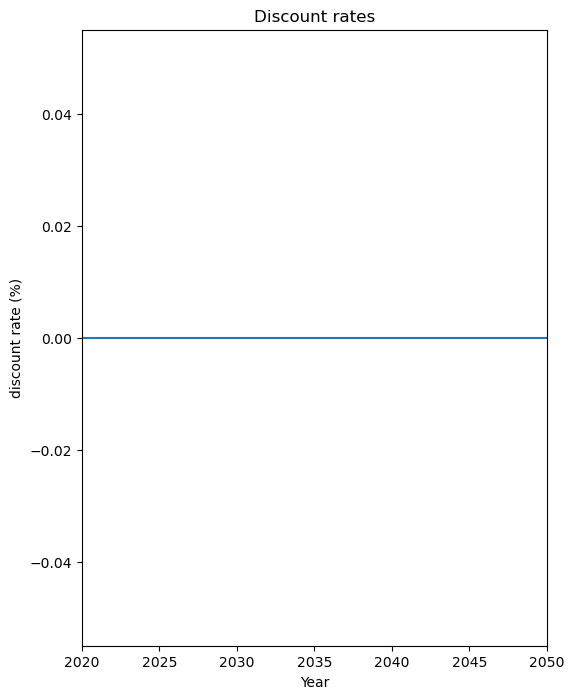

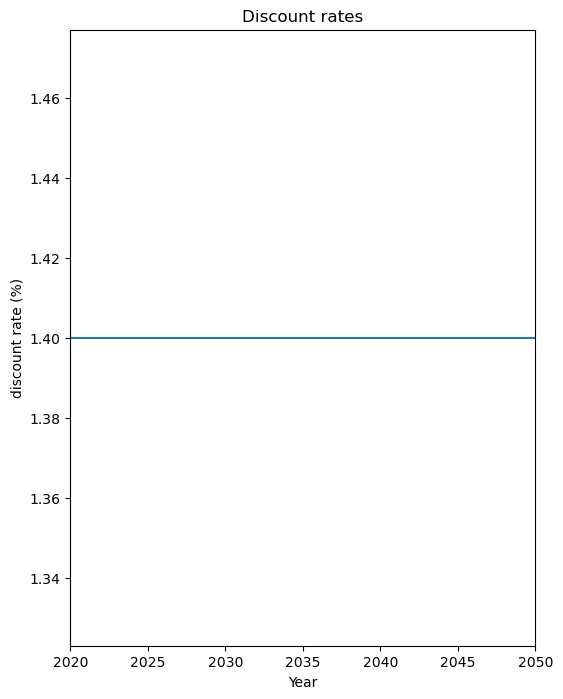

In [168]:
from climada.entity import DiscRates

year_range = np.arange( present_year, future_year + 1)
n_years = len(year_range)
annual_discount_zero = np.zeros(n_years)
annual_discount_stern = np.ones(n_years) * 0.014

# Create discount rates with zero and Stern's discount rates
discount_zero = DiscRates(year_range, annual_discount_zero)
discount_stern = DiscRates(year_range, annual_discount_stern)
# Plot the discount rates
discount_zero.plot(label='Zero Discount Rate')
discount_stern.plot(label='Stern Discount Rate')

Decide on a discount rate

In [169]:
# Create the entity for the present climate scenario
disc_rate = discount_zero  # discount_zero or discount_stern

# 7 – Measures

In the new CLIMADA update, measures can now generate **mapper functions** that take a CLIMADA object  
and transform it into another CLIMADA object of the same type, in any customized way.

### 7.1 Make the mappers

#### 7.1.1 Make the exposure mapper

In [170]:
from typing import Optional
# from climada.entity import Exposures

def make_exposure_mapper(
    canopy_df: pd.DataFrame,
    spec_to_fcn: dict,
):
    """
    Returns a function exp_mapper(exposure_present_, year) -> Exposures
    with all other arguments fixed from this scope.
    """

    def exp_mapper( exposure_present: Optional["Exposures"] = None,
                    year: Optional[int] = None
                    ):
        return make_exposures_from_canopy_df(
            canopy_df=canopy_df,
            exposure_present=exposure_present,
            spec_to_fcn=spec_to_fcn,
        )

    return exp_mapper


Try the mapper

In [171]:
# present exposures (baseline)
exp_present = make_exposures_from_canopy_df(
    canopy_df=canopy_crop_dict['present'],
    spec_to_fcn=spec_to_fcn
)
# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

# mapper that will (for now) ignore `year` but keeps a compatible signature
# Make the exposures for the second condition (e.g., 'future' or 'alternative')
alternative_name = list(canopy_crop_dict.keys())[1]  # Use the second condition
exp_mapper = make_exposure_mapper(
    canopy_df=canopy_crop_dict[alternative_name],
    spec_to_fcn=spec_to_fcn
)

# later in your code
exp_new = exp_mapper(exposure_present=exp_present)  # year ignored
# Print the Exposures object to verify
print(f"Exposures object for {alternative_name}") 
print(tabulate(exp_new.gdf, headers='keys', tablefmt='psql'))


Exposures object for 'present' condition:
+----+----------------+---------------------+--------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------+------------------+---------+------------------------------+
|    | Plot ID        | Region              | Region_key   | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |   site_id |   Per-tree shading (%) scaled |   Shade contr

OBS - chnage later

In [172]:
from tabulate import tabulate

func = make_exposures # or make_exposures_from_canopy_df
# Loop through each canopy_df in the dictionary
for comp_name, canopy_df in canopy_crop_dict.items():
    # Make exposures
    if comp_name == 'present':
        exp = func(
            canopy_df=canopy_df,
            spec_to_fcn=spec_to_fcn
        )
    else:
        exp = func(
            canopy_df=canopy_df,
            exposure_present=exp_present,  # Use the previous exposures as base
            spec_to_fcn=spec_to_fcn
        )
    
    # Calculate sums
    total_value = exp.gdf['value'].sum()
    total_main_value = exp.gdf.loc[exp.gdf['Role'] == 'Main', 'value'].sum()
    
    # Print results
    print(f"=== {comp_name} ===")
    print(f"Total value: {total_value:.2f} {exp.value_unit}")
    print(f"Total value (Role='Main'): {total_main_value:.2f} {exp.value_unit}")
    print()


2025-08-17 00:03:02,878 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
=== present ===
Total value: 9750.00 USD
Total value (Role='Main'): 1200.00 USD

2025-08-17 00:03:02,908 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
=== present_adjusted_-50 ===
Total value: 5572.13 USD
Total value (Role='Main'): 1332.13 USD

2025-08-17 00:03:02,913 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
=== present_adjusted_-38 ===
Total value: 6480.35 USD
Total value (Role='Main'): 1314.35 USD

2025-08-17 00:03:02,920 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
=== present_adjusted_-27 ===
Total value: 7344.10 USD
Total value (Role='Main'): 1290.10 USD

2025-08-17 00:03:02,924 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
=== present_adjus

#### 7.1.2 Make the impact function set mapper

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 2: Assumed Yield Loss (Cacao)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 3: Theobroma cacao site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 4: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 5: Theobroma cacao site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 6: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 7: Theobroma cacao site 2'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 8: Coffea arabica site 2'}, xlabel='Intensity (°C)', 

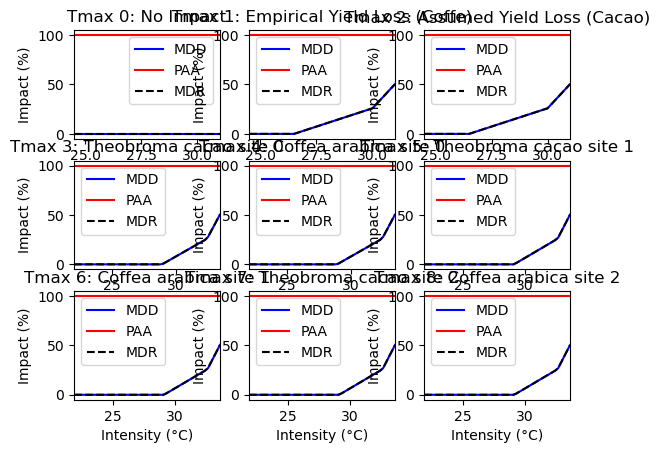

In [173]:
from typing import Optional
import pandas as pd
from climada.entity import ImpactFuncSet

def make_impf_set_mapper(
    canopy_df: pd.DataFrame,
    adjust_fcn,
    imp_fun_set_base: ImpactFuncSet
):
    """
    Returns a function impf_set_mapper(imp_fun_set_base, year) -> ImpactFuncSet
    with all other arguments fixed from this scope.
    """

    def impf_set_mapper(
        imp_fun_set: ImpactFuncSet,
        year: Optional[int] = None
    ) -> ImpactFuncSet:
        return create_adjusted_impact_function_set(
            canopy_df=canopy_df,
            imp_fun_set_base=imp_fun_set_base,
            adjust_fcn=adjust_fcn,
        )

    return impf_set_mapper


adjusted_impf_set = create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict[list(canopy_crop_dict.keys())[0]],  # Use the first sheet as the base
    imp_fun_set_base=imp_fun_set_base,
    adjust_fcn=adjust_fcn
)

adjusted_impf_set.plot()

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 2: Assumed Yield Loss (Cacao)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 3: Theobroma cacao site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 4: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 5: Theobroma cacao site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 6: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 7: Theobroma cacao site 2'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 8: Coffea arabica site 2'}, xlabel='Intensity (°C)', 

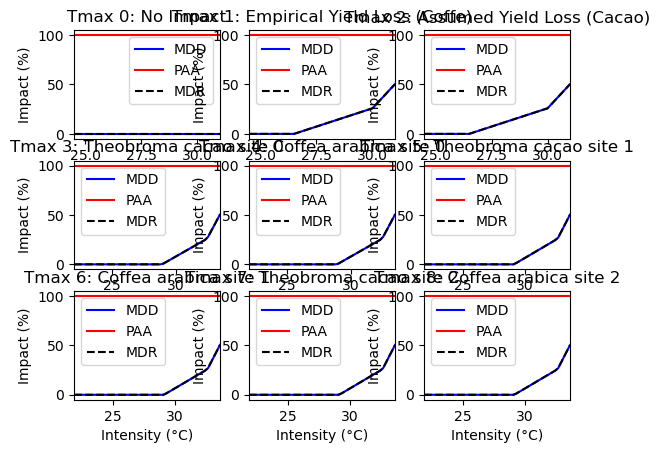

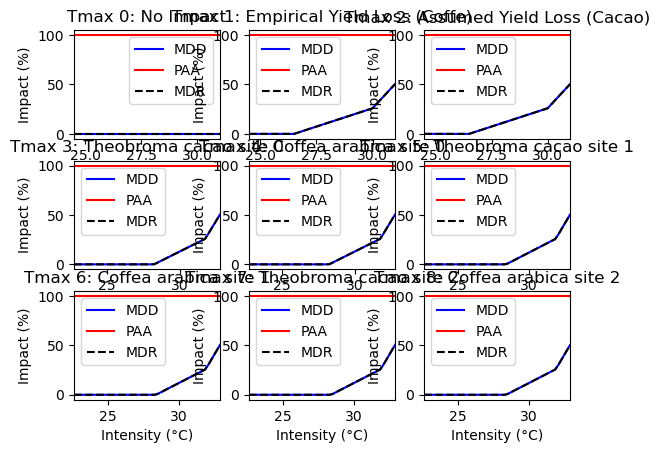

In [174]:
# Get the impact fucntion set for the present compostition
impf_set_present =  create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict['present'],  # Use the first sheet as the base
    adjust_fcn=adjust_fcn
)

# Get the impact fucntion set for the alternatvie
alternative_name = list(canopy_crop_dict.keys())[3]  # Use the second condition
impf_set_mapper = make_impf_set_mapper(canopy_df= canopy_crop_dict[alternative_name],
                                       adjust_fcn = adjust_fcn,
                                       imp_fun_set_base = imp_fun_set_base
)


new_impf_set = impf_set_mapper(impf_set_present)

impf_set_present.plot()
new_impf_set.plot()

### 7.2 Define the measures

In [175]:
from climada.engine.option_appraisal.appraiser import MeasuresAppraiser

# Define the measure
from climada.entity.measures.base import Measure
from climada.entity.measures import MeasureSet
from climada.entity.measures.cost_income import CostIncome

In [176]:
# Define a measure list
meas_list = []

# Make the measures for each composition in the canopy_crop_dict except 'present'
for comp in canopy_crop_dict.keys():
    if comp == 'present':
        continue
    else:
        # Get the canopy DataFrame for the composition
        canopy_df = canopy_crop_dict[comp]
        # Define the measure
        meas = Measure( haz_type= hazard_type,  # Use the hazard type defined earlier
                        name = comp,
                        # Make the exposures mapper
                        exposures_change = make_exposure_mapper(canopy_df=canopy_df,
                                                                spec_to_fcn=spec_to_fcn
                                                                ),
                        # Make the impact function set mapper
                        impfset_change = make_impf_set_mapper(canopy_df= canopy_df,
                                                                adjust_fcn = adjust_fcn,
                                                                imp_fun_set_base=imp_fun_set_base
                                                                ),
                        # Make the cost income from the canopy_df and costs_df
                        #cost_cashflows_df, _ = make_cashflows_costs(canopy_df, costs_df, years=10)
                        cost_income = make_cost_income_from_canopy_df(canopy_df=canopy_crop_dict[comp],
                                                                        costs_df=costs_df,
                                                                        column='Added'  # 'Added' or 'total'
                                                                    )
                        )
        # Add to the measure list
        meas_list.append(meas)


Try the measures

Exposures object for 'present' condition:
+----+----------------+---------------------+--------------+----------+------------------+---------------------------+--------------------+-----------+-------------+------------+----------------+---------------------+----------------------+------------------------+----------------------------+-------------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------+------------------+---------+------------------------------+
|    | Plot ID        | Region              | Region_key   | System   |   Plot size (ha) | Species                   | Scientific name    | Role      |   Plants/ha |   Kg/plant |   Tonnes/plant |   Yield (t/ha/year) |   Price/tonnes (USD) |   Per-tree shading (%) |   Planting cost (per tree) |   Maintenance cost (per tree) |   site_id |   Per-tree shading (%) scaled |   Shade contr

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 2: Assumed Yield Loss (Cacao)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 3: Theobroma cacao site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 4: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 5: Theobroma cacao site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 6: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 7: Theobroma cacao site 2'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 8: Coffea arabica site 2'}, xlabel='Intensity (°C)', 

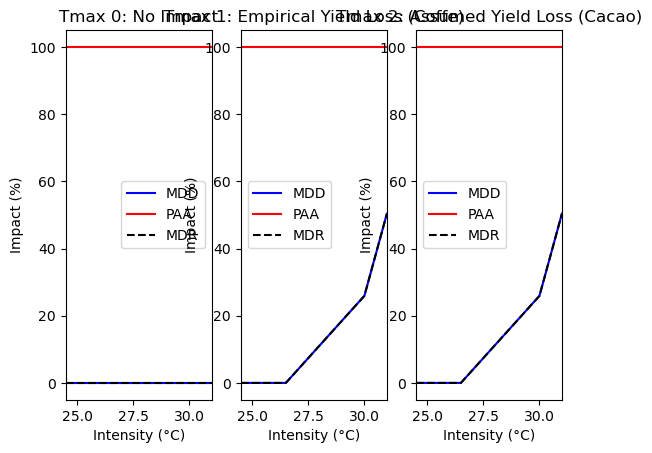

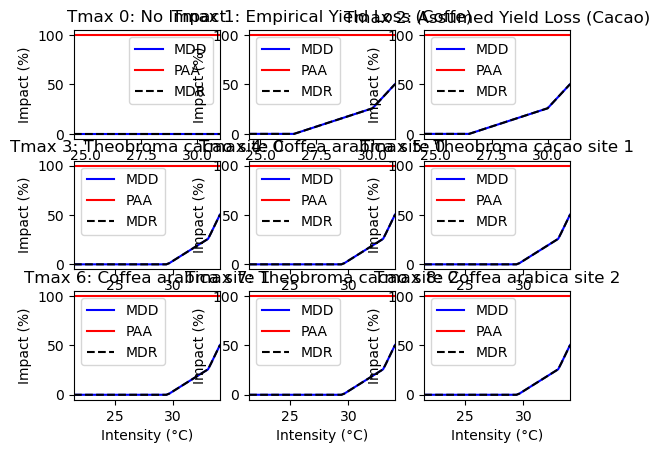

In [177]:
exp_new, impf_set_new, haz_new = meas.apply(exposures = exp_present,
                                            impfset = imp_fun_set_base,
                                            hazard = haz_dict['today']  # Use the hazard for today (or 'present' condition
)


# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

# Print the Exposures object to verify
print(f"Exposures object for {alternative_name}") 
print(tabulate(exp_new.gdf, headers='keys', tablefmt='psql'))

imp_fun_set_base.plot()
impf_set_new.plot()

In [178]:
# Gather all measures in a measure set
meas_set = MeasureSet(measures=meas_list)

# 8 – Cost and Revenue Estimates (Add Average Canopy)

In this stage, we manually calculate the costs and benefits by estimating yield for both the present and the future under different canopy scenarios.  
To calculate the future yield, we account for the risk difference between scenarios, adjusting for changes in canopy cover.


### 8.1 – Calculate Impacts

- Compute the **Annual Average Loss (AAL)** to estimate the expected NPV.  
- Calculate the **return period (RP)** losses to reflect revenue in a bad year.

In [179]:
from calendar import c
from climada.engine import ImpactCalc

# Initialize dictionaries to store results:
# - impacts_dict will hold Impact objects for each scenario and composition
# - exp_dict will hold Exposure objects for each scenario and composition
impacts_dict = {
    'today': {},   # Impacts for present-day baseline and measures
    'future': {}   # Impacts for future climate conditions
}
exp_dict = copy.deepcopy(impacts_dict)

# --- Create baseline (present) exposure and impact function set ---

# Create an adjusted impact function set for the present condition
# This modifies the base impact functions according to canopy cover (cooling effect)
impf_set_present = create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict['present'],
    adjust_fcn=adjust_fcn,                     # Function to adjust impact curve by canopy
    imp_fun_set_base=imp_fun_set_base          # Base impact function set (unadjusted)
)

# Create the exposure object for the present condition
# This assigns asset values and metadata to each site based on the present canopy composition
exp_present = make_exposures_from_canopy_df(
    canopy_df=canopy_crop_dict['present'],
    spec_to_fcn=spec_to_fcn                     # Mapping from species to impact function ID
)

# --- Loop over climate scenarios ('today' and 'future') ---
for climate_scenario in ['today', 'future']:
    haz = haz_dict[climate_scenario]  # Select hazard object for this scenario

    # Loop over all canopy compositions (baseline + adaptation measures)
    for comp in canopy_crop_dict.keys():

        # If this is the baseline 'present' composition, use the already prepared exposure and IFS
        if comp == 'present':
            exp = exp_present
            ifs = impf_set_present

        # If this is an alternative composition (adaptation measure)
        else:
            meas = meas_set.measures()[comp]     # Retrieve the measure object by name
            # Apply the measure to the present exposure & impact functions
            # This can modify exposure (e.g., yield, value), impact functions, and hazards
            exp, ifs, _ = meas.apply(exp_present, impf_set_present, haz)

        # --- Calculate and store results ---
        # Compute the impact for this exposure, impact function set, and hazard
        impacts_dict[climate_scenario][comp] = ImpactCalc(exp, ifs, haz).impact(save_mat=False)

        # Store the exposure (only for 'today' scenario to avoid duplication)
        if climate_scenario == 'today':
            exp_dict[climate_scenario][comp] = exp


### 8.2 – Calculate the Cost and Revenue Metrics

In this step, compute the key financial metrics for each canopy composition and climate scenario, including:  
- **Total Costs** – Planting, maintenance, and replacement over the analysis period.  
- **Total Revenues** – Estimated from yield–canopy relationships and adjusted for hazard impacts.  
- **Net Present Value (NPV)** – Discounted costs and revenues over time.  
- **Benefit–Cost Ratio (BCR)** – Ratio of total benefits to total costs.  
- **Net Benefits** – Revenues minus costs after discounting.

We perform this step-wise, as the future revenue is estimated based on the change in climate risk.  
We begin by retrieving the **Annual Average Loss (AAL)** and **return period losses** for each scenario to quantify  
expected revenue reductions in both normal and bad years.

In [180]:
import pandas as pd
from numpy import interp

rows = []

return_period = 30  # Example return period in years (used for bad-year loss calculation)

# Loop over all canopy compositions for the 'today' scenario
for comp in impacts_dict['today'].keys():

    # --- COSTS ---
    # Calculate the net present value (NPV) of total costs for this composition
    # make_cashflows_costs() returns a tuple, where index [1]['total'] is the NPV of total costs
    npv_total = make_cashflows_costs(
        canopy_df=canopy_crop_dict[comp],  # canopy composition DataFrame
        costs_df=costs_df,                 # cost data
        disc_rate=disc_rate                 # discount rate
    )[1]['total']

    # --- REVENUES (Present Scenario) ---
    # Get the exposure GeoDataFrame for 'today' and this composition
    exp_today = exp_dict['today'][comp].gdf

    # Total average annual revenue (sum of all site values)
    total_today = exp_today['value'].sum()

    # Average revenue for main crop only
    total_main = exp_today.loc[exp_today['Role'] == 'Main', 'value'].sum()

    # Average revenue for secondary crops
    total_secondary = exp_today.loc[exp_today['Role'] == 'Secondary', 'value'].sum()

    # --- AAL (Annual Average Loss) ---
    # Aggregate AAL (total) for today and future
    aal_today_total = impacts_dict['today'][comp].aai_agg
    aal_future_total = impacts_dict['future'][comp].aai_agg

    # AAL for main crop only
    idx_main = exp_today['Role'] == 'Main'
    aal_today_main = impacts_dict['today'][comp].eai_exp[idx_main].sum()
    aal_future_main = impacts_dict['future'][comp].eai_exp[idx_main].sum()

    # AAL for secondary crops
    idx_secondary = exp_today['Role'] == 'Secondary'
    aal_today_secondary = impacts_dict['today'][comp].eai_exp[idx_secondary].sum()
    aal_future_secondary = impacts_dict['future'][comp].eai_exp[idx_secondary].sum()

    # --- BAD-YEAR IMPACTS (Return Period Losses) ---
    # Calculate the impact frequency curve (IFC) for today
    ifc_today = impacts_dict['today'][comp].calc_freq_curve()
    # Interpolate the loss at the chosen return period (e.g., 1-in-30 year event)
    bad_year_today_total = interp(return_period, ifc_today.return_per, ifc_today.impact)

    # Do the same for the future scenario
    ifc_future = impacts_dict['future'][comp].calc_freq_curve()
    bad_year_future_total = interp(return_period, ifc_future.return_per, ifc_future.impact)

    # --- STORE RESULTS ---
    rows.append({
        "Composition": comp,
        "Avg. canopy cover": exp_today['canopy_cover'].mean(),  # average canopy % for this comp
        "Costs (NPV)": npv_total,

        # Revenue metrics (today)
        "Avg. Revenue – Total (today)": total_today,
        "Avg. Revenue – Main (today)": total_main,
        "Avg. Revenue – Secondary (today)": total_secondary,

        # AAL metrics
        "_AAL – Total (today)": aal_today_total,
        "_AAL – Main (today)": aal_today_main,
        "_AAL – Secondary (today)": aal_today_secondary,
        "_AAL – Total (future)": aal_future_total,
        "_AAL – Main (future)": aal_future_main,
        "_AAL – Secondary (future)": aal_future_secondary,

        # Bad-year impacts (total only here, but could split by crop type)
        "_Bad year impact – Total (today)": bad_year_today_total,
        "_Bad year impact – Total (future)": bad_year_future_total
    })

# Create DataFrame from collected rows
df_abs = pd.DataFrame(rows)  # Preserves insertion order for columns
print(tabulate(df_abs, headers='keys', tablefmt='psql'))


+----+----------------------+---------------------+---------------+--------------------------------+-------------------------------+------------------------------------+------------------------+-----------------------+----------------------------+-------------------------+------------------------+-----------------------------+------------------------------------+-------------------------------------+
|    | Composition          |   Avg. canopy cover |   Costs (NPV) |   Avg. Revenue – Total (today) |   Avg. Revenue – Main (today) |   Avg. Revenue – Secondary (today) |   _AAL – Total (today) |   _AAL – Main (today) |   _AAL – Secondary (today) |   _AAL – Total (future) |   _AAL – Main (future) |   _AAL – Secondary (future) |   _Bad year impact – Total (today) |   _Bad year impact – Total (future) |
|----+----------------------+---------------------+---------------+--------------------------------+-------------------------------+------------------------------------+-----------------------

Calcualte the estimated future revenue

In [181]:
import pandas as pd

est_values_rows = []

for _, row in df_abs.iterrows():
    npv_total = row["Costs (NPV)"]

    # ==== TOTAL ====
    total_today = row["Avg. Revenue – Total (today)"]
    aal_today_total_pct = (row["_AAL – Total (today)"] / total_today) * 100
    aal_future_total_pct = (row["_AAL – Total (future)"] / total_today) * 100

    bad_year_today_total = total_today - (
        row["_Bad year impact – Total (today)"] - row["_AAL – Total (today)"]
    )
    total_future_total = (total_today / (1 - aal_today_total_pct / 100)) * (1 - aal_future_total_pct / 100)
    bad_year_future_total = total_future_total - (
        (row["_Bad year impact – Total (future)"] - row["_AAL – Total (future)"]) / total_today * total_future_total
    )

    # ==== MAIN ====
    main_today = row["Avg. Revenue – Main (today)"]
    aal_today_main_pct = (row["_AAL – Main (today)"] / main_today) * 100 if main_today > 0 else np.nan
    aal_future_main_pct = (row["_AAL – Main (future)"] / main_today) * 100 if main_today > 0 else np.nan
    main_future = (main_today / (1 - aal_today_main_pct / 100)) * (1 - aal_future_main_pct / 100) 

    # ==== SECONDARY ====
    secondary_today = row["Avg. Revenue – Secondary (today)"]
    aal_today_secondary_pct = (row["_AAL – Secondary (today)"] / secondary_today) * 100 if secondary_today > 0 else np.nan
    aal_future_secondary_pct = (row["_AAL – Secondary (future)"] / secondary_today) * 100 if secondary_today > 0 else  np.nan
    secondary_future = (secondary_today / (1 - aal_today_secondary_pct / 100)) * (1 - aal_future_secondary_pct / 100)

    est_values_rows.append({
        "Composition": row["Composition"],
        "Avg. canopy cover": row["Avg. canopy cover"],
        "Costs (NPV)": npv_total,

        # Total
        "Avg. Revenue – Total (today)": total_today,
        "AAL % – Total (today)": aal_today_total_pct,
        "AAL % – Total (future)": aal_future_total_pct,
        "Avg. Revenue - Bad Year – Total (today)": bad_year_today_total,
        "Avg. Revenue – Total (future)": total_future_total,
        "Avg. Revenue - Bad Year – Total (future)": bad_year_future_total,

        # Main
        "Avg. Revenue – Main (today)": main_today,
        "AAL % – Main (today)": aal_today_main_pct,
        "AAL % – Main (future)": aal_future_main_pct,
        "Avg. Revenue – Main (future)": main_future,

        # Secondary
        "Avg. Revenue – Secondary (today)": secondary_today,
        "AAL % – Secondary (today)": aal_today_secondary_pct,
        "AAL % – Secondary (future)": aal_future_secondary_pct,
        "Avg. Revenue – Secondary (future)": secondary_future
    })

# Create DataFrame
est_values_df = pd.DataFrame(est_values_rows)
print(tabulate(est_values_df, headers="keys", tablefmt="psql"))

# # Print the average revenu for the main for today and future for eahc composition
print("Average Revenue for Main (today):")
print(tabulate(est_values_df[["Composition", "Avg. Revenue – Main (today)", "Avg. Revenue – Main (future)"]], headers="keys", tablefmt="psql"))

+----+----------------------+---------------------+---------------+--------------------------------+-------------------------+--------------------------+-------------------------------------------+---------------------------------+--------------------------------------------+-------------------------------+------------------------+-------------------------+--------------------------------+------------------------------------+-----------------------------+------------------------------+-------------------------------------+
|    | Composition          |   Avg. canopy cover |   Costs (NPV) |   Avg. Revenue – Total (today) |   AAL % – Total (today) |   AAL % – Total (future) |   Avg. Revenue - Bad Year – Total (today) |   Avg. Revenue – Total (future) |   Avg. Revenue - Bad Year – Total (future) |   Avg. Revenue – Main (today) |   AAL % – Main (today) |   AAL % – Main (future) |   Avg. Revenue – Main (future) |   Avg. Revenue – Secondary (today) |   AAL % – Secondary (today) |   AAL % – S

### 8.2.1 – Future Revenue & Risk Attribution (relative to baseline **c**)

We work only with **present raw revenue** $Y_p(\cdot)$ and AAL fractions.

#### Notation
- Baseline canopy: $c$. Alternative: $c'$.
- Present raw revenue at canopy $x$: $Y_p(x)$.
- AAL fractions: $\mathrm{AAL}_p(x),\ \mathrm{AAL}_f(x)\in[0,1)$.
- **Retention (future vs present)**:
$$
R(x)=\frac{1-\mathrm{AAL}_f(x)}{1-\mathrm{AAL}_p(x)}.
$$
- **Gain ratio (present canopy effect)**:
$$
g(c',c)=\frac{Y_p(c')}{Y_p(c)}, \qquad \text{so } g(c,c)=1.
$$
- **Risk ratio (relative retention)**:
$$
r(c',c)=\frac{R(c')}{R(c)}.
$$

---

#### Core equations

**Future revenue if you keep vs. switch**
$$
Y_f(c')=Y_p(c')\,R(c')=Y_p(c)\,g(c',c)\,R(c').
$$

**Decision rule (is switching beneficial?)**
$$
\rho=\frac{Y_f(c')}{Y_f(c)} = g(c',c)\,r(c',c).
$$
Beneficial iff $\rho>1$.

---

#### Present-year attribution (using present AALs)

**Total present change**
$$
\Delta Y_{\text{present}}(c',c)
= Y_p(c') - Y_p(c).
$$

**Risk attribution (present)**
$$
\Delta\mathrm{risk}_{\text{present}}(c',c)
= Y_p(c)\,\Big([1-\mathrm{AAL}_p(c')]-[1-\mathrm{AAL}_p(c)]\Big).
$$

**Gain attribution (present)**
$$
\Delta\mathrm{gain}_{\text{present}}(c',c)
=\Delta Y_{\text{present}}(c',c)-\Delta\mathrm{risk}_{\text{present}}(c',c).
$$

---

#### Risk-first attribution (future)

**Total future change**
$$
\Delta Y_{\text{future}}(c',c)=Y_f(c')-Y_f(c).
$$

**Risk attribution (future)**
$$
\Delta\mathrm{risk}_{\text{future}}(c',c)=Y_p(c)\,\big[R(c')-R(c)\big].
$$

**Gain attribution (future) — simplified**
$$
\Delta\mathrm{gain}_{\text{future}}(c',c)
=\Delta Y_{\text{future}}(c',c)-\Delta\mathrm{risk}_{\text{future}}(c',c).
$$

---

*All AAL inputs must be **fractions** (e.g., $5\%\Rightarrow 0.05$).*


### 8.3 – Make some adhoc analysis adn risk attribution

In [182]:
import numpy as np
import pandas as pd

def derive_gain_risk_from_est(
    est_values_df: pd.DataFrame,
    baseline: str = "present",
    segment: str = "Total",           # "Total" | "Main" | "Secondary"
    risk_mode: str = "future_only",   # default now matches the equations above
) -> pd.DataFrame:
    """
    Derive:
      - g(c',c), r(c',c), decision ratios,
      - present & future risk-first attributions (with future risk via R by default).

    Notes:
      - ΔY_present uses raw Yp: Yp(c') - Yp(c)
      - Δrisk_future uses R: Yp(c) * (R(c') - R(c))
      - Δgain_* is always the residual: ΔY_* - Δrisk_*
    """

    seg_tok = {"total": "Total", "main": "Main", "secondary": "Secondary"}[
        segment.strip().lower()
    ]
    col_y_today  = f"Avg. Revenue – {seg_tok} (today)"   # Yp(x)
    col_y_future = f"Avg. Revenue – {seg_tok} (future)"  # Yf(x)
    col_aalp     = f"AAL % – {seg_tok} (today)"
    col_aalf     = f"AAL % – {seg_tok} (future)"

    df = est_values_df.copy()
    df["Segment"] = seg_tok

    # Inputs
    df["Yp"] = df[col_y_today]
    df["Yf"] = df[col_y_future]
    df["AALp_frac"] = df[col_aalp] / 100.0
    df["AALf_frac"] = df[col_aalf] / 100.0

    # Retention R(x) = (1 - AALf) / (1 - AALp)
    denom = (1 - df["AALp_frac"])
    df["R"] = np.where(denom > 0, (1 - df["AALf_frac"]) / denom, np.nan)

    # Baseline values (c)
    base = df.loc[df["Composition"] == baseline]
    if base.empty:
        raise ValueError(f"Baseline '{baseline}' not found.")
    base = base.iloc[0]
    Yp_c, Yf_c = base["Yp"], base["Yf"]
    AALp_c, AALf_c, R_c = base["AALp_frac"], base["AALf_frac"], base["R"]

    # Ratios and decisions
    df["g(c,c′)"] = df["Yp"] / Yp_c                     # gain ratio
    df["r(c,c′)"] = df["R"] / R_c                       # risk ratio
    df["ρ_future = Yf/Yf_baseline"] = df["Yf"] / Yf_c   # equals g*r if Yf=Yp*(1-AALf)
    df["Beneficial_vs_future_baseline"] = df["ρ_future = Yf/Yf_baseline"] > 1

    # --- Present attribution (using present AALs) ---
    df["ΔY_present"]    = df["Yp"] - Yp_c
    df["Δrisk_present"] = Yp_c * ((1 - df["AALp_frac"]) - (1 - AALp_c))
    df["Δgain_present"] = df["ΔY_present"] - df["Δrisk_present"]

    # --- Future attribution ---
    df["ΔY_future"] = df["Yf"] - Yf_c

    if risk_mode == "retention_R":
        df["Δrisk_future"] = Yp_c * (df["R"] - R_c)
    elif risk_mode == "future_only":
        df["Δrisk_future"] = Yp_c * ((1 - df["AALf_frac"]) - (1 - AALf_c))
    else:
        raise ValueError("risk_mode must be 'retention_R' or 'future_only'")

    df["Δgain_future"] = df["ΔY_future"] - df["Δrisk_future"]

    keep_cols = [
        "Composition","Segment",
        *(["Avg. canopy cover"] if "Avg. canopy cover" in df.columns else []),
        *(["Costs (NPV)"] if "Costs (NPV)" in df.columns else []),
        "Yp","Yf","AALp_frac","AALf_frac","R",
        "g(c,c′)","r(c,c′)",
        "ρ_future = Yf/Yf_baseline","Beneficial_vs_future_baseline",
        "ΔY_present","Δrisk_present","Δgain_present",
        "ΔY_future","Δrisk_future","Δgain_future",
    ]
    return df[keep_cols]

# Derive gain and risk from the estimated values DataFrame
df_gain_risk = derive_gain_risk_from_est(
    est_values_df=est_values_df,
    baseline='present',  # Use 'present' as the baseline composition
    segment='Main',     # Analyze total segment
)
print(tabulate(df_gain_risk, headers='keys', tablefmt='psql'))

+----+----------------------+-----------+---------------------+---------------+----------+----------+-------------+-------------+----------+-----------+-----------+-----------------------------+---------------------------------+--------------+-----------------+-----------------+-------------+----------------+----------------+
|    | Composition          | Segment   |   Avg. canopy cover |   Costs (NPV) |       Yp |       Yf |   AALp_frac |   AALf_frac |        R |   g(c,c′) |   r(c,c′) |   ρ_future = Yf/Yf_baseline | Beneficial_vs_future_baseline   |   ΔY_present |   Δrisk_present |   Δgain_present |   ΔY_future |   Δrisk_future |   Δgain_future |
|----+----------------------+-----------+---------------------+---------------+----------+----------+-------------+-------------+----------+-----------+-----------+-----------------------------+---------------------------------+--------------+-----------------+-----------------+-------------+----------------+----------------|
|  0 | present  

Plot the values

In [183]:
from narwhals import col
import numpy as np
import matplotlib.pyplot as plt

def plot_yield_attribution_grouped(
    est_values_df,
    baseline="present",
    segment="Main",        # "Total" | "Main" | "Secondary"
    view="future",         # "present" | "future"
    sort_by=None,          # None | "delta" | "risk" | "gain"
    relative=False,        # False -> absolute deltas; True -> relative to baseline (%)
    risk_mode="retention_R",   # "retention_R" | "future_only" (passed to derive function)
    figsize=(11,5),
):
    """
    Draw grouped bars (Δrisk, Δgain) with a line for ΔY total.
    If relative=True, normalize by the baseline revenue:
        - future view  -> divide by Yf(baseline)
        - present view -> divide by Yp(baseline)
    and show results in percent.
    """
    # Build attribution table
    df = derive_gain_risk_from_est(
        est_values_df, baseline=baseline, segment=segment, risk_mode=risk_mode
    )

    # Choose columns
    if view.lower() == "future":
        d_total, d_risk, d_gain = "ΔY_future", "Δrisk_future", "Δgain_future"
        base_den_col = "Yf"   # relative normalization uses future baseline
        ylab = "Δ Future Revenue"
        title_tag = "Future"
    else:
        d_total, d_risk, d_gain = "ΔY_present", "Δrisk_present", "Δgain_present"
        base_den_col = "Yp"   # relative normalization uses present baseline
        ylab = "Δ Present Revenue"
        title_tag = "Present"

    # Optional sort (on the chosen metric)
    if sort_by == "delta":
        df = df.sort_values(d_total)
    elif sort_by == "risk":
        df = df.sort_values(d_risk)
    elif sort_by == "gain":
        df = df.sort_values(d_gain)

    # Compute normalization for relative view
    if relative:
        base_row = df.loc[df["Composition"] == baseline]
        if base_row.empty:
            raise ValueError(f"Baseline '{baseline}' not found in results.")
        denom = float(base_row.iloc[0][base_den_col])
        if denom == 0 or np.isnan(denom):
            raise ValueError(f"Baseline denominator for '{base_den_col}' is zero/NaN; cannot compute relative values.")

        df["_risk_plot"]  = (df[d_risk]  / denom) * 100.0
        df["_gain_plot"]  = (df[d_gain]  / denom) * 100.0
        df["_total_plot"] = (df[d_total] / denom) * 100.0
        ylab = ylab + " (% of baseline)"
    else:
        df["_risk_plot"]  = df[d_risk]
        df["_gain_plot"]  = df[d_gain]
        df["_total_plot"] = df[d_total]

    # X positions
    x = np.arange(len(df))
    width = 0.35
    off   = width / 2

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    # Grouped bars
    ax.bar(x - off, df["_risk_plot"].fillna(0).values, width, label="Δrisk")
    ax.bar(x + off, df["_gain_plot"].fillna(0).values, width, label="Δgain")

    # Total delta as a line (no explicit color to follow your style rule) and black line
    ax.plot(x, df["_total_plot"].values, marker="o", linewidth=2, label="ΔY total", color="black")

    # Cosmetics
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(df["Composition"].tolist(), rotation=45, ha="right")
    ax.set_ylabel(ylab)
    rel_tag = " (relative)" if relative else ""
    ax.set_title(f"Annual Revenue difference vs baseline '{baseline}' — {segment} — {title_tag}{rel_tag}")
    # grid and legend
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    return fig, ax


FIX: Add realtive decrease and increase as y plot and fix for the present

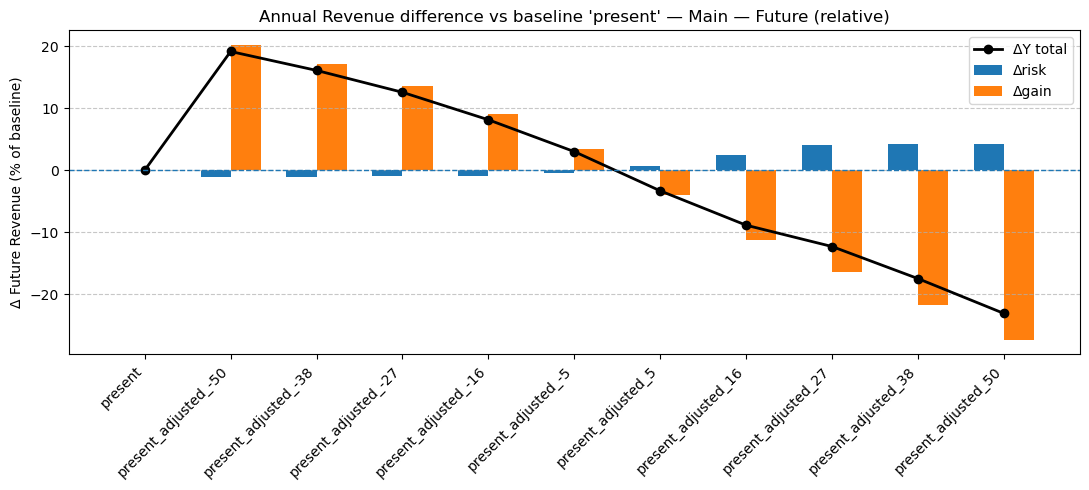

In [194]:
# example: future, Main, with future-only risk split

# Add relative 
df_attr = derive_gain_risk_from_est(est_values_df, baseline="present",
                                    segment="Main", risk_mode="future_only")
fig, ax = plot_yield_attribution_grouped(est_values_df,
                                         baseline="present",
                                         segment="Main",
                                         view="future",
                                         sort_by=None,
                                        relative=True,
                                        risk_mode="future_only",
                                        figsize=(11, 5))

Analyze the yield to canopy

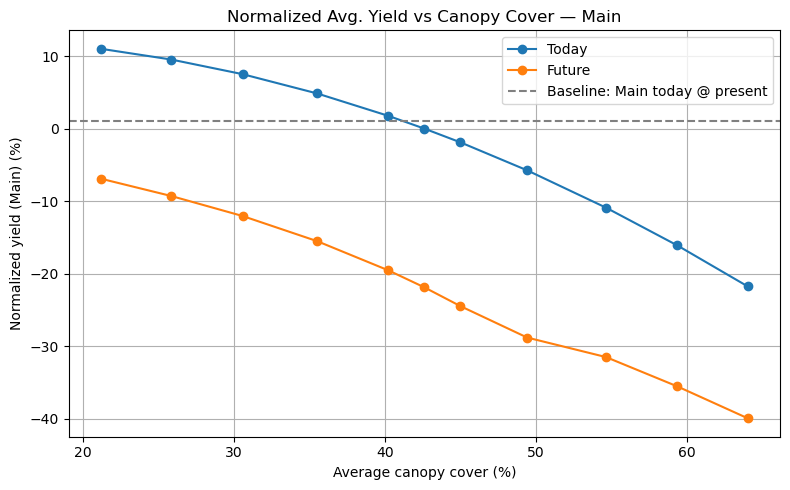

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

def plot_normalized_yield(
    df,
    role='Main',                 # 'Total' | 'Main' | 'Secondary'
    baseline_comp='present',     # composition to normalize against
    show_labels=False,
    normalize_to='today',        # 'today' (default) | 'future' | 'custom'
    custom_denominator=None,     # if normalize_to='custom', provide a scalar
):
    """
    Plot normalized average yield vs canopy cover for today and future.

    Normalization:
      - 'today'  : divide BOTH series by Y_today(baseline)  ← recommended
      - 'future' : divide BOTH series by Y_future(baseline)
      - 'custom' : divide BOTH series by custom_denominator (scalar)
    """
    # Column names based on role
    col_today  = f"Avg. Revenue – {role} (today)"
    col_future = f"Avg. Revenue – {role} (future)"

    # Validate columns
    for c in (col_today, col_future, "Composition", "Avg. canopy cover"):
        if c not in df.columns:
            raise ValueError(f"Column '{c}' not found in DataFrame.")

    # Get baseline row
    base = df.loc[df["Composition"] == baseline_comp]
    if base.empty:
        raise ValueError(f"Baseline composition '{baseline_comp}' not found.")

    baseline_today  = float(base.iloc[0][col_today])
    baseline_future = float(base.iloc[0][col_future])

    # Pick common denominator
    if normalize_to == 'today':
        denom = baseline_today
        den_label = f"{role} today @ {baseline_comp}"
    elif normalize_to == 'future':
        denom = baseline_future
        den_label = f"{role} future @ {baseline_comp}"
    elif normalize_to == 'custom':
        if custom_denominator is None or custom_denominator == 0:
            raise ValueError("Provide a non-zero custom_denominator when normalize_to='custom'.")
        denom = float(custom_denominator)
        den_label = "custom baseline"
    else:
        raise ValueError("normalize_to must be 'today', 'future', or 'custom'.")

    # Work on a copy to avoid mutating caller's df
    d = df.copy()

    # Normalize BOTH series with the SAME denominator in terms of procentage
    d['Yield_norm_today']  = (d[col_today]  / denom - 1.0 )*100 # subtract 1 to show relative change
    d['Yield_norm_future'] = (d[col_future] / denom - 1.0 )*100 # subtract 1 to show relative change

    # Sort by canopy for a nice line plot
    d = d.sort_values('Avg. canopy cover')

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(d['Avg. canopy cover'], d['Yield_norm_today'],  marker='o', label='Today')
    plt.plot(d['Avg. canopy cover'], d['Yield_norm_future'], marker='o', label='Future')

    # Optional labels
    if show_labels:
        for _, r in d.iterrows():
            plt.text(r['Avg. canopy cover'], r['Yield_norm_today'],  r['Composition'],
                     fontsize=8, ha='right', va='bottom')
            plt.text(r['Avg. canopy cover'], r['Yield_norm_future'], r['Composition'],
                     fontsize=8, ha='left',  va='bottom')

    # Baseline line = 1 (since both normalized to same denom)
    plt.axhline(1.0, color='grey', linestyle='--', label=f'Baseline: {den_label}')

    plt.xlabel('Average canopy cover (%)')
    plt.ylabel(f'Normalized yield ({role}) (%)')
    plt.title(f'Normalized Avg. Yield vs Canopy Cover — {role}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage
plot_df = est_values_df.copy()
plot_df = plot_df[plot_df['Composition'] != 'cacao_to_coffee']
plot_normalized_yield(plot_df, role='Main', baseline_comp='present', show_labels=False)

Plot the exposure attribution

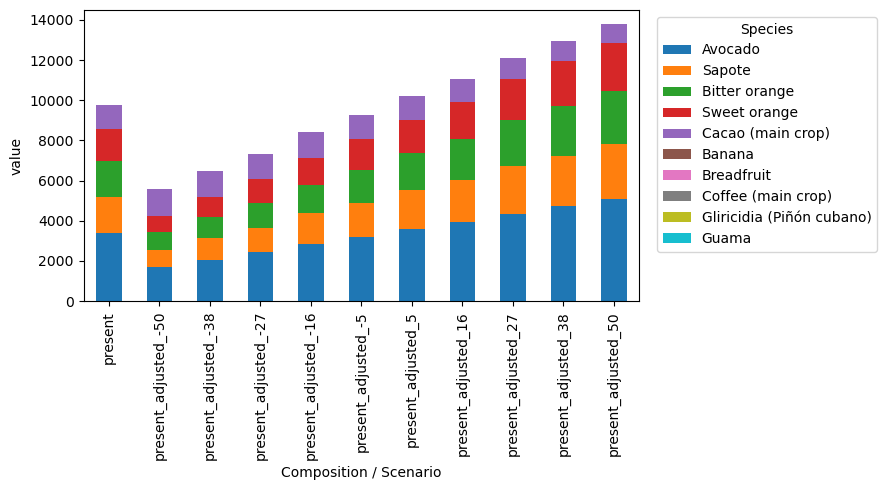

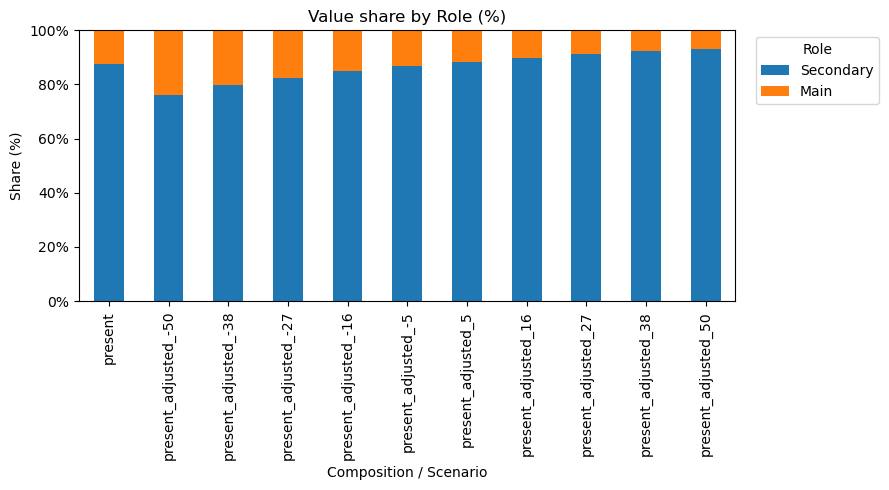

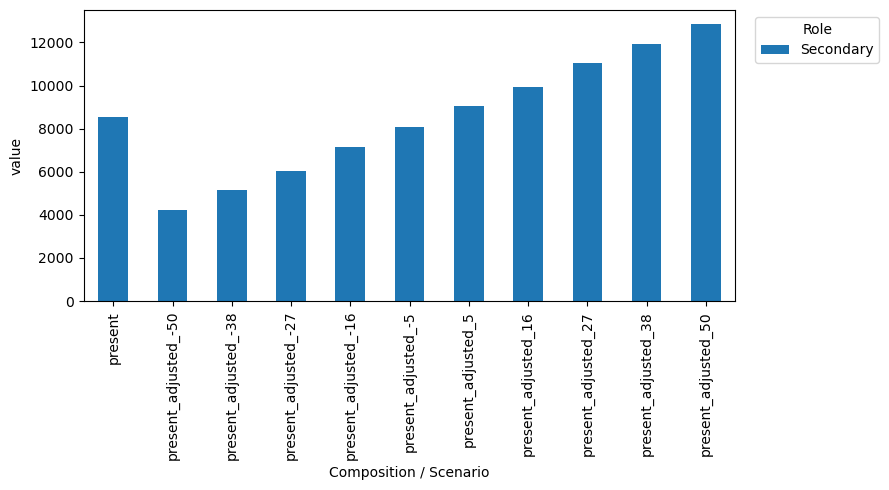

(<Axes: xlabel='Composition / Scenario', ylabel='value'>,
 Role                  Secondary
 comp                           
 present                  8550.0
 present_adjusted_-50     4240.0
 present_adjusted_-38     5166.0
 present_adjusted_-27     6054.0
 present_adjusted_-16     7146.0
 present_adjusted_-5      8066.0
 present_adjusted_5       9034.0
 present_adjusted_16      9922.0
 present_adjusted_27     11046.0
 present_adjusted_38     11934.0
 present_adjusted_50     12860.0)

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_value_stacked_simple(
    exp_dict,
    group_col='Species',      # e.g. 'Role' or 'Species'
    day='today',
    subset=None,              # list of group_col values to show (others -> "Other" or dropped)
    include_other=True,       # if True, non-subset groups collapse to "Other"; if False, they’re dropped
    as_percent=False,         # if True, each bar sums to 100%
    title=None,
    figsize=(9, 5)
):
    """
    Stacked bars by `group_col` across compositions (exp_dict[day].keys()).
    Minimal API. Use `subset` to control which groups appear in the stack.

    Parameters
    ----------
    exp_dict : dict
        exp_dict[day][comp] must have a .gdf (or be a DataFrame) with columns:
        [group_col, 'value'].
    group_col : str
        Column to stack (e.g., 'Role', 'Species').
    day : str
        'today' or any key present in exp_dict.
    subset : list[str] | None
        Which values of `group_col` to display. If None, use all.
    include_other : bool
        If True and subset is provided, aggregate all non-subset groups under 'Other'.
        If False, drop non-subset groups entirely.
    as_percent : bool
        Plot each bar as shares (100%) if True, else absolute values.
    title : str | None
        Optional plot title.
    figsize : tuple
        Figure size.
    """
    comps = list(exp_dict[day].keys())
    frames = []

    for comp in comps:
        df = exp_dict[day][comp].gdf if hasattr(exp_dict[day][comp], "gdf") else exp_dict[day][comp]
        if group_col not in df.columns or 'value' not in df.columns:
            raise ValueError(f"Missing column(s) in '{comp}': need '{group_col}' and 'value'")

        tmp = df.groupby(group_col, as_index=False)['value'].sum()
        tmp['comp'] = comp
        frames.append(tmp)

    tall = pd.concat(frames, ignore_index=True)
    tall['comp'] = pd.Categorical(tall['comp'], categories=comps, ordered=True)

    # Apply subset logic
    if subset is not None:
        subset = set(subset)
        if include_other:
            tall.loc[~tall[group_col].isin(subset), group_col] = 'Other'
        else:
            tall = tall[tall[group_col].isin(subset)]

    # Pivot to wide
    wide = (tall.pivot_table(index='comp', columns=group_col, values='value', aggfunc='sum')
                 .fillna(0))

    # Order stacks by total height
    wide = wide[wide.sum(axis=0).sort_values(ascending=False).index]

    # Normalize to 100% if requested
    if as_percent:
        row_sums = wide.sum(axis=1).replace(0, np.nan)
        wide = (wide.div(row_sums, axis=0).fillna(0) * 100)

    ax = wide.plot(kind='bar', stacked=True, figsize=figsize)
    ax.set_xlabel('Composition / Scenario')
    ax.set_ylabel(f"{'Share (%)' if as_percent else 'value'}")
    if as_percent:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.set_ylim(0, 100)

    if title:
        ax.set_title(title)

    ax.legend(title=group_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return ax, wide

# 1) Absolute values stacked by Species (all groups)
plot_value_stacked_simple(exp_dict, group_col='Species', day='today')

# 2) Percentage shares by Role, only show Main/Secondary (others -> 'Other')
plot_value_stacked_simple(
    exp_dict, group_col='Role', day='today',
    subset=['Main', 'Secondary'], include_other=True, as_percent=True,
    title='Value share by Role (%)'
)

# 3) Only show a chosen subset (drop everything else)
plot_value_stacked_simple(
    exp_dict, group_col='Role', day='today',
    subset=['Secondary'], include_other=False
)


## 8.4 – Calcualte the net pesent and cost-benefit and plot

Estimate the net present value of the revenue streams

In [187]:
import numpy as np
import pandas as pd


inflation_rate = 0.02  # 2% annual
npv_rows = []

# Calculate NPV for each role in each composition
for _, row in est_values_df.iterrows():
    role_data = {}
    role_data["Composition"] = row["Composition"]

    for role in ["Total", "Main", "Secondary"]:
        rev_today = row.get(f"Avg. Revenue – {role} (today)", 0)
        rev_future = row.get(f"Avg. Revenue – {role} (future)", 0)

        if pd.isna(rev_today) or pd.isna(rev_future) or rev_today == 0:
            role_data[f"Revenue (NPV) – {role}"] = 0
            continue

        # Linear interpolation between today and future over 'years'
        years = future_year - present_year + 1
        yearly_revenues = np.linspace(rev_today, rev_future, years)

        # Apply inflation rate (or other growth parameter)
        yearly_revenues = yearly_revenues * (1 + inflation_rate) ** np.arange(1, years + 1)

        # Discount to get NPV
        npv = disc_rate.net_present_value(present_year, future_year, yearly_revenues)
        role_data[f"Revenue (NPV) – {role}"] = npv

    npv_rows.append(role_data)

df_npv = pd.DataFrame(npv_rows)
print(df_npv)

# check the NPV total equaals the sum of the individual roles for each row
df_npv["Revenue (NPV) – Total calc"] = df_npv[["Revenue (NPV) – Main", "Revenue (NPV) – Secondary"]].sum(axis=1)
npv_total_check = np.allclose(df_npv["Revenue (NPV) – Total"], df_npv["Revenue (NPV) – Total calc"])
print("NPV Total matches sum of roles:", npv_total_check)
print("NPV Total for each composition:")
print(tabulate(df_npv[["Composition", "Revenue (NPV) – Total", "Revenue (NPV) – Total calc"]], headers='keys', tablefmt='psql'))
# Print the NPV total check result
print(f"NPV Total check: {npv_total_check}")


             Composition  Revenue (NPV) – Total  Revenue (NPV) – Main  \
0                present          417223.934940          45597.118179   
1   present_adjusted_-50          237495.792601          52447.045900   
2   present_adjusted_-38          276604.040945          51418.886282   
3   present_adjusted_-27          313803.775529          50158.671789   
4   present_adjusted_-16          359459.619278          48548.017968   
5    present_adjusted_-5          397389.640470          46680.551304   
6     present_adjusted_5          436938.625994          44412.862856   
7    present_adjusted_16          473053.509498          42274.727537   
8    present_adjusted_27          519460.877108          40308.479314   
9    present_adjusted_38          555390.798815          37938.924966   
10   present_adjusted_50          592751.881440          35368.214976   

    Revenue (NPV) – Secondary  
0               369591.103123  
1               183282.605525  
2               223310.8349

Calculate the net and the benefit of comparing the present 

In [188]:
baseline = "present"

# 1) Keep the role NPVs in your metrics table (you removed them in the final reordering)
df_cb_metrics = est_values_df.merge(df_npv, on="Composition", how="left")

df_cb_metrics = df_cb_metrics[[
    "Composition",
    "Costs (NPV)",
    "Revenue (NPV) – Total",
    "Revenue (NPV) – Main",
    "Revenue (NPV) – Secondary",
    "Avg. Revenue – Total (today)",
    "Avg. Revenue – Total (future)",
    "Avg. Revenue - Bad Year – Total (today)",
    "Avg. Revenue - Bad Year – Total (future)",
]]

# 2) Net, Benefit, BCR (as you had)
df_cb_metrics["Net (NPV)"] = df_cb_metrics["Revenue (NPV) – Total"] - df_cb_metrics["Costs (NPV)"]
baseline_net = df_cb_metrics.loc[df_cb_metrics['Composition'] == baseline, 'Net (NPV)'].values[0]
df_cb_metrics['Benefit'] = df_cb_metrics['Net (NPV)'] - baseline_net
df_cb_metrics['BCR'] = df_cb_metrics['Benefit'] / df_cb_metrics['Costs (NPV)']

# 3) Δ vs baseline components for the attribution plot
b = df_cb_metrics.loc[df_cb_metrics["Composition"] == baseline].iloc[0]
df_cb_metrics["ΔRev Main (NPV)"]      = df_cb_metrics["Revenue (NPV) – Main"]      - b["Revenue (NPV) – Main"]
df_cb_metrics["ΔRev Secondary (NPV)"] = df_cb_metrics["Revenue (NPV) – Secondary"] - b["Revenue (NPV) – Secondary"]
df_cb_metrics["ΔCost (NPV)"]          = df_cb_metrics["Costs (NPV)"]               - b["Costs (NPV)"]

# (optional) consistency check: Benefit = ΔRev Main + ΔRev Secondary − ΔCost
df_cb_metrics["Benefit_check"] = (
    df_cb_metrics["ΔRev Main (NPV)"] + df_cb_metrics["ΔRev Secondary (NPV)"] - df_cb_metrics["ΔCost (NPV)"]
)
# Print the final metrics DataFrame
print(tabulate(df_cb_metrics, headers='keys', tablefmt='psql'))

+----+----------------------+---------------+-------------------------+------------------------+-----------------------------+--------------------------------+---------------------------------+-------------------------------------------+--------------------------------------------+-------------+-----------+-----------+-------------------+------------------------+---------------+-----------------+
|    | Composition          |   Costs (NPV) |   Revenue (NPV) – Total |   Revenue (NPV) – Main |   Revenue (NPV) – Secondary |   Avg. Revenue – Total (today) |   Avg. Revenue – Total (future) |   Avg. Revenue - Bad Year – Total (today) |   Avg. Revenue - Bad Year – Total (future) |   Net (NPV) |   Benefit |       BCR |   ΔRev Main (NPV) |   ΔRev Secondary (NPV) |   ΔCost (NPV) |   Benefit_check |
|----+----------------------+---------------+-------------------------+------------------------+-----------------------------+--------------------------------+---------------------------------+-------

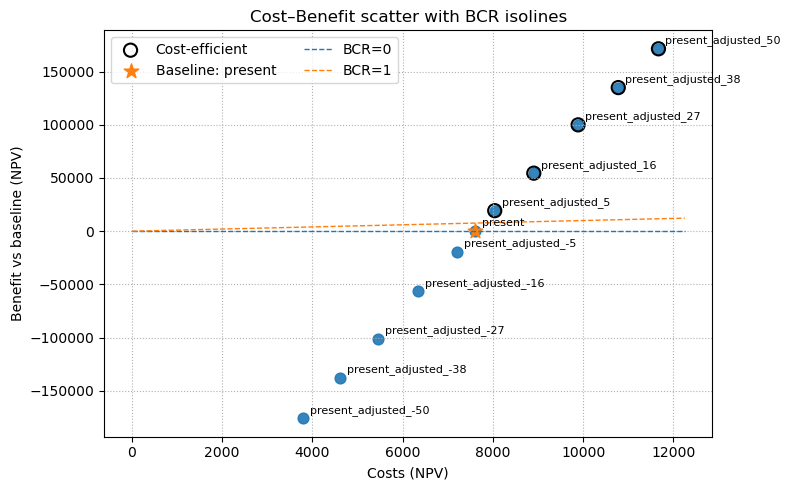

In [189]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cost_vs_benefit(
    df_cb_metrics,
    baseline="present",
    label_points=True,
    iso_bcr=(0, 1),     # lines of constant Benefit = BCR * Cost
    highlight_rule=lambda r: (r["BCR"] >= 1) and (r["Benefit"] > 0),
    figsize=(8,5),
):
    d = df_cb_metrics.copy()

    x = d["Costs (NPV)"].values
    y = d["Benefit"].values
    bcr = d["BCR"].values
    names = d["Composition"].astype(str).values

    fig, ax = plt.subplots(figsize=figsize)

    # Scatter
    sc = ax.scatter(x, y, s=60, alpha=0.9)

    # Highlight “cost-efficient”: BCR >= 1 and Benefit > 0 (by default)
    mask_eff = np.array([highlight_rule(r) for _, r in d.iterrows()])
    ax.scatter(x[mask_eff], y[mask_eff], s=90, facecolors='none', edgecolors='k', linewidths=1.5, label="Cost-efficient")

    # Mark baseline
    i0 = int(d.index[d["Composition"] == baseline][0]) if (d["Composition"] == baseline).any() else None
    if i0 is not None:
        ax.scatter([x[i0]], [y[i0]], s=120, marker="*", label=f"Baseline: {baseline}")

    # BCR isolines: Benefit = (BCR) * Cost
    x_line = np.linspace(0, max(x)*1.05 if len(x) else 1, 200)
    for k in iso_bcr:
        ax.plot(x_line, k * x_line, linestyle="--", linewidth=1, label=f"BCR={k}")

    # Labels
    if label_points:
        for xi, yi, nm in zip(x, y, names):
            ax.annotate(nm, (xi, yi), xytext=(5, 4), textcoords="offset points", fontsize=8)

    ax.set_xlabel("Costs (NPV)")
    ax.set_ylabel("Benefit vs baseline (NPV)")
    ax.set_title("Cost–Benefit scatter with BCR isolines")
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.legend(loc="best", ncol=2)
    fig.tight_layout()
    return fig, ax

# Example:
fig, ax = plot_cost_vs_benefit(df_cb_metrics, baseline="present", label_points=True)


In [190]:
from turtle import color
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cb_roles_with_bcr(
    df_cb_metrics: pd.DataFrame,
    df_npv: pd.DataFrame = None,          # provide if role NPVs aren't in df_cb_metrics
    baseline: str = "present",
    figsize=(12,5),
    sort_by: str = None,                  # None | "BCR" | "Benefit" | "Cost"
):
    """
    Left y-axis: grouped bars per composition
        - ΔBenefit total (NPV)  ← emphasized, separate bar
        - ΔRev Main (NPV)
        - ΔRev Secondary (NPV)
        - ΔCost (NPV)
    Right y-axis: BCR (Total) as a line.
    All deltas are relative to the baseline composition.

    Needs columns:
      'Composition','Costs (NPV)','BCR' (or 'Benefit' + 'Costs (NPV)'),
      and role NPVs: 'Revenue (NPV) – Main','Revenue (NPV) – Secondary'
      (either already in df_cb_metrics or passed via df_npv).
    """
    d = df_cb_metrics.copy()

    # Ensure role NPVs exist
    role_cols = ["Revenue (NPV) – Main", "Revenue (NPV) – Secondary"]
    if any(c not in d.columns for c in role_cols):
        if df_npv is None:
            raise ValueError("Role NPVs missing. Pass df_npv with 'Revenue (NPV) – Main/Secondary'.")
        d = d.merge(df_npv[["Composition"] + role_cols], on="Composition", how="left")

    # Baseline
    b = d.loc[d["Composition"] == baseline]
    if b.empty:
        raise ValueError(f"Baseline '{baseline}' not found.")
    b = b.iloc[0]

    # Deltas vs baseline
    d["ΔRev Main (NPV)"]      = d["Revenue (NPV) – Main"]      - b["Revenue (NPV) – Main"]
    d["ΔRev Secondary (NPV)"] = d["Revenue (NPV) – Secondary"] - b["Revenue (NPV) – Secondary"]
    d["ΔCost (NPV)"]          = d["Costs (NPV)"]               - b["Costs (NPV)"]
    d["ΔBenefit (NPV)"]       = d["ΔRev Main (NPV)"] + d["ΔRev Secondary (NPV)"] - d["ΔCost (NPV)"]

    if "BCR" not in d.columns and {"Benefit","Costs (NPV)"} <= set(d.columns):
        d["BCR"] = d["Benefit"] / d["Costs (NPV)"]

    # Optional sort
    if sort_by == "BCR":
        d = d.sort_values("BCR")
    elif sort_by == "Benefit" and "Benefit" in d.columns:
        d = d.sort_values("Benefit")
    elif sort_by == "Cost":
        d = d.sort_values("ΔCost (NPV)")

    # Positions
    x = np.arange(len(d))
    w = 0.22
    off_total = -1.5 * w
    off_main  = -0.5 * w
    off_seco  =  0.5 * w
    off_cost  =  1.5 * w

    fig, ax = plt.subplots(figsize=figsize)

    # --- Emphasized total benefit (its own bar) ---
    ax.bar(
        x + off_total, d["ΔBenefit (NPV)"].values, width=w,
        facecolor="none", edgecolor="black", linewidth=1.8, hatch="////",
        label="ΔBenefit total (NPV)"
    )

    # --- Role benefits and cost (grouped) ---
    ax.bar(x + off_main, d["ΔRev Main (NPV)"].fillna(0).values, width=w, label="ΔRev Main (NPV)")
    ax.bar(x + off_seco, d["ΔRev Secondary (NPV)"].fillna(0).values, width=w, label="ΔRev Secondary (NPV)")
    ax.bar(x + off_cost, d["ΔCost (NPV)"].fillna(0).values, width=w, label="ΔCost (NPV)")

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["Composition"].tolist(), rotation=45, ha="right")
    ax.set_ylabel("Δ value vs baseline (NPV, currency)")
    ax.set_title("Benefits by role and Costs vs baseline, with BCR (Total)")

    # Right axis: BCR line + reference at 1
    ax2 = ax.twinx()
    ax2.plot(x, d["BCR"].values, marker="o", linewidth=2, label="BCR (Total)", color="purple")
    # Reference line at BCR=1 and have as a legend
    ax2.axhline(1.0, linestyle=":", linewidth=3, color="purple", label="BCR = 1") # Reference line at BCR=1
    ax2.set_ylabel("BCR (Benefit / Cost)")

    # Combine legends
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best", ncol=2)

    # Expand x-limits so outer bars aren’t clipped
    ax.set_xlim(x.min() - 2*w, x.max() + 2*w)

    fig.tight_layout()
    return fig, ax, ax2


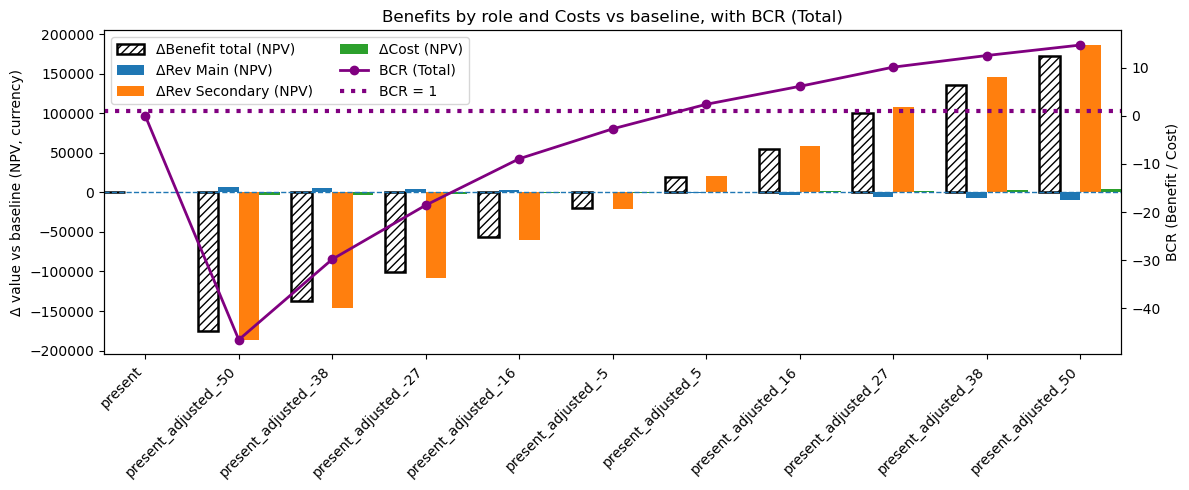

In [191]:
fig, ax, ax2 = plot_cb_roles_with_bcr(
    df_cb_metrics=df_cb_metrics,
    df_npv=df_npv,            # provide if role NPVs aren't already merged
    baseline="present",
    sort_by=None
)


# 9 –Extra material

## 9.1 – Add biodiversity and multicriteria

## 9.2 - Use other yield-to-canopy curves

## 9.3 - Use other impact function

## 9.3 - Suggestions of uncertainty modeling and guidence

- Cooling
- Yield to canopy
- Impact fucntion


As a final we add the biodiversity metric

## 9 – Cost and Revenue estimates with Uncertainties

- Yield-canopy curve
- Cooling curve
- Impact function

### 9.1 - Define the uncertainty variables

In [192]:
import copy
import scipy as sp
from functools import partial

from climada.engine.unsequa import InputVar

## Define the uncertainty variables for the exposure, impact function set, and hazard
# Exposure
exp_distr = {
    "e_optimal_canopy": sp.stats.uniform(loc=20, scale=50),  # Uniform distribution between 20 and 40 for optimal canopy cover
}

# # Impact function set
# impf_distr = {
#     "i_seed": sp.stats.randint(low=1, high=100), # Uniform distribution between 1 and 100 determines the random seed for the impact function
#     "i_cooling": sp.stats.uniform(loc=0, scale=10),  # Uniform distribution between 0 and 10 for cooling effect
# }

# Uniform between 20 and 40
e_optimal_canopy = sp.stats.uniform(loc=20, scale=20)
mu_new = e_optimal_canopy.rvs()

print(f"Optimal canopy cover: {mu_new:.2f} %")


Optimal canopy cover: 21.84 %


Yield to canopy curve

+-----+-------------+-------------+
|     |   Shade (%) |   Yield (%) |
|-----+-------------+-------------|
|   0 |           0 |     90.625  |
|   1 |           1 |     92.4025 |
|   2 |           2 |     94      |
|   3 |           3 |     95.4025 |
|   4 |           4 |     96.625  |
|   5 |           5 |     97.6525 |
|   6 |           6 |     98.5    |
|   7 |           7 |     99.1525 |
|   8 |           8 |     99.625  |
|   9 |           9 |     99.9025 |
|  10 |          10 |    100      |
|  11 |          11 |     99.9875 |
|  12 |          12 |     99.955  |
|  13 |          13 |     99.9025 |
|  14 |          14 |     99.83   |
|  15 |          15 |     99.7375 |
|  16 |          16 |     99.625  |
|  17 |          17 |     99.4875 |
|  18 |          18 |     99.33   |
|  19 |          19 |     99.1525 |
|  20 |          20 |     98.955  |
|  21 |          21 |     98.7375 |
|  22 |          22 |     98.5    |
|  23 |          23 |     98.2375 |
|  24 |          24 |     97

TypeError: 'functools.partial' object is not subscriptable

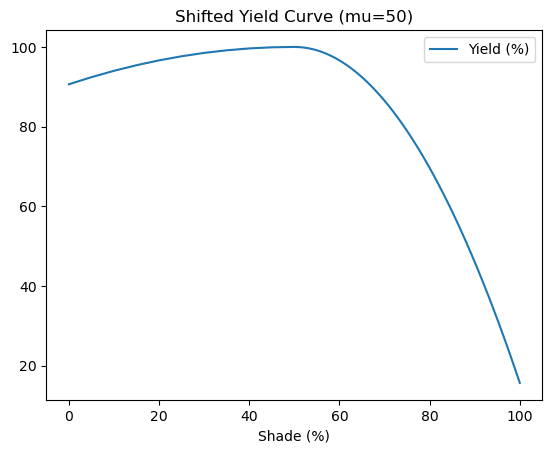

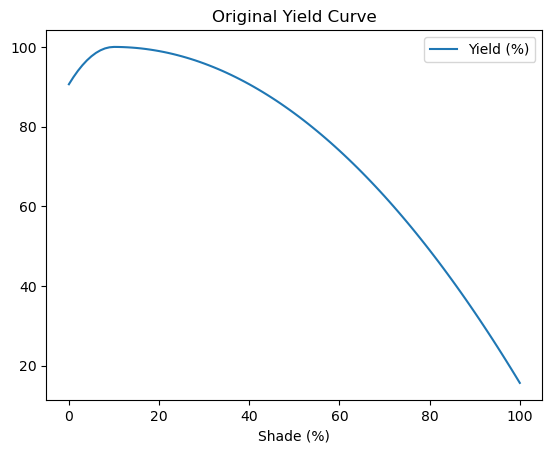

In [193]:
print(tabulate(shade_vs_yield_curve_COFFE, headers='keys', tablefmt='psql'))

import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

def shift_peak_by_interpolation(df, mu_new):
    # Original x, y
    x = df["Shade (%)"].to_numpy(dtype=float)
    y = df["Yield (%)"].to_numpy(dtype=float)

    # Detect old peak location
    mu_old = x[np.argmax(y)]

    # Split original curve at old peak
    left_mask  = x <= mu_old
    right_mask = x >= mu_old

    # Progress variables on each side (0→1 toward the peak)
    p_left  = (x[left_mask] / mu_old)
    p_right = (x[right_mask] - mu_old) / (100.0 - mu_old)

    # Interpolation functions
    def y_left_of(p):
        return np.interp(p, p_left, y[left_mask])
    def y_right_of(p):
        return np.interp(p, p_right, y[right_mask])

    # Build new curve
    y_new = np.empty_like(x, dtype=float)

    # Left of new peak
    left_new = x <= mu_new
    pL = np.divide(x[left_new], mu_new, out=np.zeros_like(x[left_new]), where=mu_new>0)
    y_new[left_new] = y_left_of(np.clip(pL, 0, 1))

    # Right of new peak
    right_new = ~left_new
    denom = (100.0 - mu_new) if mu_new < 100 else np.inf
    pR = np.divide(x[right_new] - mu_new, denom, out=np.zeros_like(x[right_new]), where=denom>0)
    y_new[right_new] = y_right_of(np.clip(pR, 0, 1))

    out = df.copy()
    out["Yield (%)"] = y_new
    return out

# Example usage:
# df_shifted = shift_peak_by_interpolation(df, mu_new=50)

# Example usage:
mu_new = 50   # you could replace this with your random draw
df = shade_vs_yield_curve_COFFE
df_new = shift_peak_by_interpolation(df, mu_new)
# Plot the new curve
df_new.plot(x="Shade (%)", y="Yield (%)", title=f"Shifted Yield Curve (mu={mu_new})")
shade_vs_yield_curve_COFFE.plot(x="Shade (%)", y="Yield (%)", title="Original Yield Curve")


# Generate random 
df = estimate_new_yield_coffe
df_new = shift_peak_by_interpolation(df, mu_new)
# Generate a new yield estimate function
estimate_new_yield_coffe_random = partial(estimate_new_yield, 
                                        shade_yield_df = shade_vs_yield_curve_COFFE) 

spec_to_fcn_random = {
    'Coffea arabica': estimate_new_yield_coffe,
}


In [ ]:
spec_to_fcn = {
    'Coffea arabica': estimate_new_yield_coffe,
    'Coffea canephora': estimate_new_yield_coffe,
    'Coffea liberica': estimate_new_yield_coffe,
    'Coffea excelsa': estimate_new_yield_coffe,
    'Theobroma cacao': estimate_new_yield_coffe  # Assuming the same function for cacao
}

In [ ]:
def exp_base_func(e_yield_canopy, exp_base=exp_base):
    # Copy the base exposure
    exp = copy.deepcopy(exp_base)
    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value
    # Scale the canopy cover by the y_canopy
    exp.gdf["canopy_cover_mean_1km"] *= e_canopy
    return exp

In [ ]:
# Hazard

## Define the uncertainty functions for the exposure, impact function set and hazard
# Exposure
exp_base = copy.deepcopy(exp_central_america)  # Make a copy of the original exposure
# Define the base exposure
def exp_base_func(e_value, e_canopy, exp_base=exp_base):
    # Copy the base exposure
    exp = copy.deepcopy(exp_base)
    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value
    # Scale the canopy cover by the y_canopy
    exp.gdf["canopy_cover_mean_1km"] *= e_canopy
    return exp
# Define the uncertainty function
exp_func = partial(exp_base_func, exp_base=exp_base)

# Impact function set
# Define the base impact function set
impf_func = lambda i_seed: ImpactFuncSet([
    generate_random_vpd_impact_func(
        seed=int(i_seed), # Use the seed from the uncertainty variable
        std_dev=0.1,
        file_path='vpd_effect_approximation.csv',
        name='Random VPD IF'
    )
])

# Hazard


## Make the uncertainty variables
exp_iv = InputVar(exp_func, exp_distr)
impf_iv = InputVar(impf_func, impf_distr)


## 10 – Risk and CB Analysis (new cost benefit module)